In [1]:
import pathlib
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
from prepare import process_regressor, model_performance_metrics,draw_scatter
from data_prune_function import get_scores,get_data,prune_rd,return_model
random_state =352
test_size = 0.1

model = {}
for modelname in ['CB','XG','GB','RF']:
    model[modelname] = return_model(modelname,random_state=random_state)

target = 'NO(%)'
df,X,y,X_train_val,X_test,y_train_val,y_test = get_data(target = target,random_state=random_state, test_size=test_size,standardized=False)
mad = (y - y.mean()).abs().mean()
std = y.std()
print('')
print('-----------------')
print(f'{target} {y.shape[0]} {mad:.3f} {std:.3f} ')
print('-----------------')


-----------------
NO(%) 242 14.156 17.853 
-----------------


In [2]:
target = 'NO(%)'
a = 'CB'
b = 'XG'
c = 'GB'
d = 'RF'

In [16]:
folder = f'{target}/{target}_{a}_guiding_pruning'
pathlib.Path(f"./{folder}").mkdir(parents=True, exist_ok=True)
file_out_a = f'{folder}/all_dat.pkl'

folder = f'{target}/{target}_{b}_guiding_pruning'
pathlib.Path(f"./{folder}").mkdir(parents=True, exist_ok=True)
file_out_b = f'{folder}/all_dat.pkl'

folder = f'{target}/{target}_{c}_guiding_pruning'
pathlib.Path(f"./{folder}").mkdir(parents=True, exist_ok=True)
file_out_c = f'{folder}/all_dat.pkl'

cv train R2: 0.685 (+/- 0.094) 

Cat Train mse: 0.00019 | rmse: 0.01389 | mae: 0.01068 | mape: 2.69917 | smape: 2.67146 | r2: 0.99380

Cat Test mse: 0.00383 | rmse: 0.06187 | mae: 0.04682 | mape: 14.87899 | smape: 13.21868 | r2: 0.89445



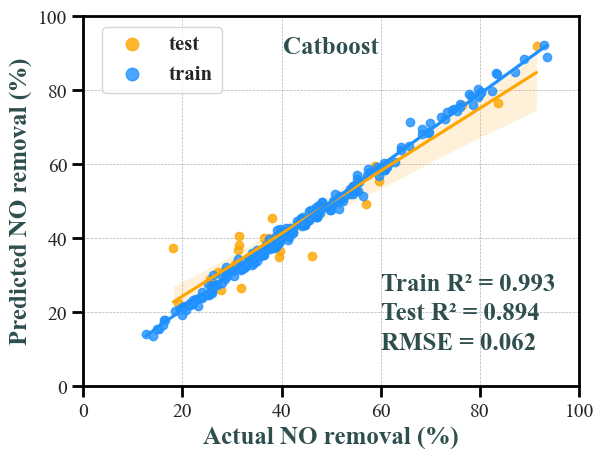

In [4]:
train_pred, test_pred = process_regressor(model[a],X_train_val,X_test,y_train_val,y_test)
model_performance_metrics('Cat Train', y_train_val, train_pred)
model_performance_metrics('Cat Test', y_test, test_pred)
draw_scatter(y_train_val, train_pred, y_test, test_pred, "Catboost", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)')

cv train R2: 0.659 (+/- 0.098) 

XGB Train mse: 0.00063 | rmse: 0.02513 | mae: 0.01943 | mape: 5.04504 | smape: 4.94009 | r2: 0.97969

XGB Test mse: 0.00443 | rmse: 0.06657 | mae: 0.05010 | mape: 15.07566 | smape: 13.30395 | r2: 0.87779

测试图已保存：scatter_images\XGBoost.jpg


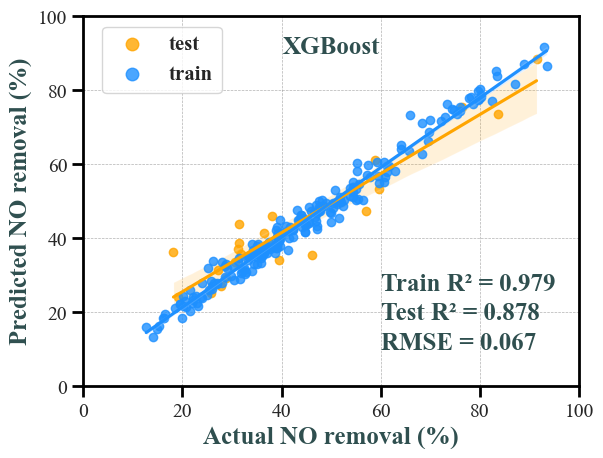

In [5]:
train_pred, test_pred = process_regressor(model[b],X_train_val,X_test,y_train_val,y_test)
model_performance_metrics('XGB Train', y_train_val, train_pred)
model_performance_metrics('XGB Test', y_test, test_pred)
draw_scatter(y_train_val, train_pred, y_test, test_pred, "XGBoost", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

cv train R2: 0.682 (+/- 0.111) 

GBDT Train mse: 0.00001 | rmse: 0.00341 | mae: 0.00276 | mape: 0.69936 | smape: 0.69737 | r2: 0.99963

GBDT Test mse: 0.00470 | rmse: 0.06857 | mae: 0.05218 | mape: 16.74918 | smape: 14.90412 | r2: 0.87036



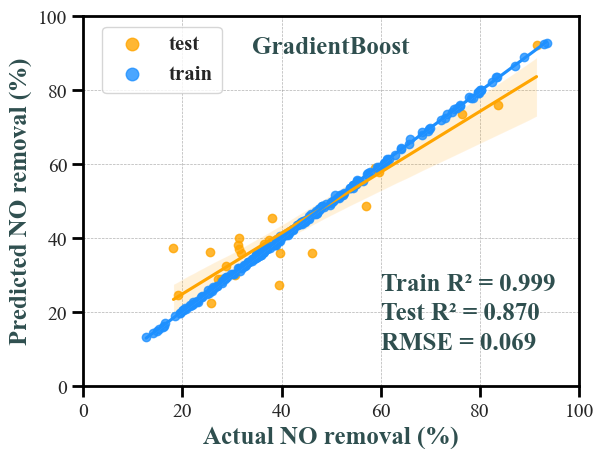

In [7]:
train_pred, test_pred = process_regressor(model[c],X_train_val,X_test,y_train_val,y_test)
model_performance_metrics('GBDT Train', y_train_val, train_pred)
model_performance_metrics('GBDT Test', y_test, test_pred)
draw_scatter(y_train_val, train_pred, y_test, test_pred, "GradientBoost", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=False)

cv train R2: 0.682 (+/- 0.111) 

RF Train mse: 0.00001 | rmse: 0.00341 | mae: 0.00276 | mape: 0.69936 | smape: 0.69737 | r2: 0.99963

RF Test mse: 0.00470 | rmse: 0.06857 | mae: 0.05218 | mape: 16.74918 | smape: 14.90412 | r2: 0.87036



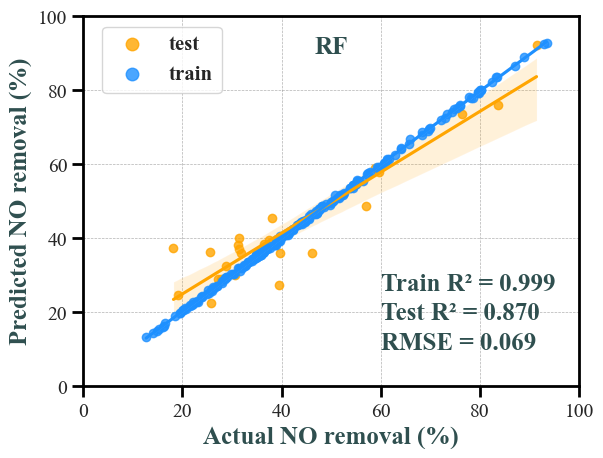

In [8]:
train_pred, test_pred = process_regressor(model[c],X_train_val,X_test,y_train_val,y_test)
model_performance_metrics('RF Train', y_train_val, train_pred)
model_performance_metrics('RF Test', y_test, test_pred)
draw_scatter(y_train_val, train_pred, y_test, test_pred, "RF", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=False)

In [9]:
maes_a, rmse_a, r2_a = get_scores(model[a], X_train_val, y_train_val, X_test, y_test)

Test scores: MAE=4.682, RMSE=6.187, R2=0.894
--- 0.6262562274932861 seconds ---



In [10]:
maes_b, rmse_b, r2_b = get_scores(model[b], X_train_val, y_train_val, X_test, y_test)

Test scores: MAE=5.010, RMSE=6.657, R2=0.878
--- 0.09219050407409668 seconds ---



In [11]:
maes_c, rmse_c, r2_c = get_scores(model[c], X_train_val, y_train_val, X_test, y_test)

Test scores: MAE=5.218, RMSE=6.857, R2=0.870
--- 0.1105806827545166 seconds ---



In [17]:
size_old_val_a, ids_a, test_scores_a, val_scores_a,test_fit_a,remove_a = prune_rd(
        model[a], X_train_val, y_train_val, X_test, y_test,max_iter=80,
        min_drop= 2,model_test= model[d],
        threshold=maes_a / 2,train_size= 0.9, file_out=file_out_a)

Iteration 0:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 0 (ratio = 0.000)
本次循环中新训练集大小，占比: 217  (ratio = 1.000)
--- 0.670982837677002 seconds ---
修剪模型：
Test scores: maes=4.616, rmse=5.952, r2=0.902
--- 0.661431074142456 seconds ---
测试模型上评分
Test scores: maes=6.378, rmse=7.820, r2=0.831
--- 0.10062217712402344 seconds ---
Iteration 1:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 4 (ratio = 0.018)
本次循环中新训练集大小，占比: 213  (ratio = 0.982)
--- 0.6188740730285645 seconds ---
修剪模型：
Test scores: maes=4.761, rmse=6.143, r2=0.896
Val scores: maes=0.916, rmse=1.228, r2=0.996
--- 0.652651309967041 seconds ---
测试模型上评分
Test scores: maes=6.511, rmse=7.675, r2=0.838
Val scores: maes=3.683, rmse=4.955, r2=0.942
--- 0.09965801239013672 seconds ---
Iteration 2:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 8 (ratio = 0.037)
本次循环中新训练集大小，占比: 209  (ratio = 0.963)
--- 0.6370797157287598 seconds ---
修剪模型：
Test scores: maes=4.604, rmse=6.107, r2=0.897
Val scores: maes=1.305, rmse=1.535, r2=0.989
--- 0.6186392307281494 seconds ---
测试模型上评分
Test scores: m

In [18]:
size_old_val_b, ids_b, test_scores_b, val_scores_b,test_fit_b,remove_b = prune_rd(
    model[b], X_train_val, y_train_val, X_test, y_test,max_iter=80,min_drop= 2,
    model_test= model[d],threshold=maes_b / 2,train_size= 0.9, file_out=file_out_b)

Iteration 0:
丢弃训练词条数量 : 3 
本次循环中 old_val 数量: 0 (ratio = 0.000)
本次循环中新训练集大小，占比: 217  (ratio = 1.000)
--- 0.10150694847106934 seconds ---
修剪模型：
Test scores: maes=4.679, rmse=6.627, r2=0.879
--- 0.09711861610412598 seconds ---
测试模型上评分
Test scores: maes=6.274, rmse=7.510, r2=0.844
--- 0.13464641571044922 seconds ---
Iteration 1:
丢弃训练词条数量 : 3 
本次循环中 old_val 数量: 3 (ratio = 0.014)
本次循环中新训练集大小，占比: 214  (ratio = 0.986)
--- 0.09421277046203613 seconds ---
修剪模型：
Test scores: maes=4.850, rmse=6.583, r2=0.881
Val scores: maes=1.333, rmse=1.345, r2=0.997
--- 0.0946953296661377 seconds ---
测试模型上评分
Test scores: maes=6.313, rmse=7.546, r2=0.843
Val scores: maes=5.121, rmse=6.805, r2=0.914
--- 0.1311647891998291 seconds ---
Iteration 2:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 6 (ratio = 0.028)
本次循环中新训练集大小，占比: 211  (ratio = 0.972)
--- 0.0847172737121582 seconds ---
修剪模型：
Test scores: maes=5.021, rmse=6.925, r2=0.868
Val scores: maes=2.694, rmse=3.108, r2=0.974
--- 0.08167433738708496 seconds ---
测试模型上评分
Test sco

In [19]:
size_old_val_c, ids_c, test_scores_c, val_scores_c,test_fit_c,remove_c = prune_rd(
        model[c], X_train_val, y_train_val, X_test, y_test,max_iter=80,
        min_drop= 2,model_test= model[d],threshold=maes_c / 2,train_size= 0.9, file_out=file_out_c)

Iteration 0:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 0 (ratio = 0.000)
本次循环中新训练集大小，占比: 217  (ratio = 1.000)
--- 0.1083841323852539 seconds ---
修剪模型：
Test scores: maes=4.817, rmse=6.352, r2=0.889
--- 0.1091768741607666 seconds ---
测试模型上评分
Test scores: maes=6.578, rmse=8.068, r2=0.821
--- 0.1008293628692627 seconds ---
Iteration 1:
丢弃训练词条数量 : 6 
本次循环中 old_val 数量: 4 (ratio = 0.018)
本次循环中新训练集大小，占比: 213  (ratio = 0.982)
--- 0.09921717643737793 seconds ---
修剪模型：
Test scores: maes=5.053, rmse=6.589, r2=0.880
Val scores: maes=2.788, rmse=3.570, r2=0.953
--- 0.10732245445251465 seconds ---
测试模型上评分
Test scores: maes=6.542, rmse=7.864, r2=0.829
Val scores: maes=1.729, rmse=2.157, r2=0.983
--- 0.10141110420227051 seconds ---
Iteration 2:
丢弃训练词条数量 : 6 
本次循环中 old_val 数量: 10 (ratio = 0.046)
本次循环中新训练集大小，占比: 207  (ratio = 0.954)
--- 0.0977640151977539 seconds ---
修剪模型：
Test scores: maes=4.936, rmse=6.514, r2=0.883
Val scores: maes=2.695, rmse=3.171, r2=0.933
--- 0.10480928421020508 seconds ---
测试模型上评分
Test sco

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from prepare import get_mse_rmse_mae_mape_smape_r2
import os
def draw_scatter_3(train_true, train_pred,val_true,val_pred,test_true, test_pred,title,
                  actual_text='actual', pred_text='prediction',save=False):

    # 统一字体设置
    plt.rcParams['font.family'] = 'Times New Roman'
    # plt.rcParams['font.sans-serif'] = ['Arial']  # 备用字体

    # 设置整张图背景颜色
    '''
    1、创建Figure时直接设置
    plt.figure(facecolor='w'))

    2、对现有的Figure设置
    plt.gcf()  #获取当前的图
    fig.set_facecolor('white')
    '''
    #设置的是整个图的颜色
    #plt.figure(facecolor='lightgrey')  #还可以使用RGB元组(0.8,0.8,0.8)取值范围0~1

    # 定义字体样式
    font_common = {
        'family': 'Times New Roman',
        'color': '#2F4F4F',  # 深灰色
        'weight': 'bold',
        'size': 18
    }

    # 绘制散点图
    #scatter_kws使用此函数控制透明度和点大小
    sns.regplot(x=train_true, y=train_pred,
                color="dodgerblue", label= 'train',
                scatter_kws = {'alpha': 0.5, 's': 18})
    sns.regplot(x=test_true, y=test_pred, color= '#FF69B4', label= 'test',
                scatter_kws = {'alpha': 0.8, 's': 30})
    sns.regplot(x=val_true, y= val_pred,
                color="orange", label="val",
                scatter_kws = {'alpha': 0.5, 's': 10})

    # 设置坐标轴标签和范围
    plt.xlabel(actual_text, fontdict=font_common,weight='bold')
    plt.ylabel(pred_text, fontdict=font_common,weight='bold')
    plt.xlim(0, 100)
    plt.ylim(0, 100)

    # 设置图例
    legend_font = {'family': 'Times New Roman', 'weight': 'bold', 'size': 15}
    plt.legend(loc="upper right", markerscale=1.5, prop=legend_font,frameon=True, bbox_to_anchor=(0.3, 0.85))
    '''
    frameon:设置图例是否具有边框，bbox_to_anchor调整图例位置
    loc:控制图例在绘图区内的基准位置，可以配合bbox_to_anchor使用
    loc:    best   0自动化选择最好位置
            upper right 右上角1
            upper left  左上角2
            lower left  左下3
            lower right 右下4
            right  垂直居中 右侧5            center left 左侧垂直居中6
    '''

    # 设置刻度
    plt.tick_params(direction="in", width=2, labelsize=14)

    #获取图中绘制的图
    ax = plt.gca()
    #设置颜色
    ax.set_facecolor('white')

    #设置边框
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor('black')

    #设置图内网格
    plt.grid(True,
             axis='both',
             linestyle='--',
             linewidth=0.5,
             color='gray',
             alpha=0.6)

    # 添加统计信息文本
    _, _, _, _, _, train_r2 = get_mse_rmse_mae_mape_smape_r2(train_true.values.ravel() / 100, train_pred / 100)
    _, _, _, _, _, val_r2 = get_mse_rmse_mae_mape_smape_r2(val_true.values.ravel() / 100, val_pred / 100)
    _, _, _, _, _, test_r2 = get_mse_rmse_mae_mape_smape_r2(test_true.values.ravel() / 100, test_pred / 100)

    plt.text(60, 26, f"Train R² = {(int(train_r2*1000)/1000):.3f}", **font_common)
    plt.text(60, 18, f"val   R² = {int(val_r2*1000)/1000:.3f}", **font_common)
    plt.text(60, 10, f"test  R² = {int(test_r2*1000)/1000:.3f}", **font_common)

    # 添加标题
    plt.text(50, 90, title, **font_common, horizontalalignment="center")

    # 保存图像
    if save:
        out_put = 'scatter_images'
        if not os.path.exists(out_put):
            os.makedirs(out_put)
        output_path = os.path.join(out_put, f'{title}.jpg')
        plt.savefig(output_path, format="jpg", dpi=600,
                    bbox_inches="tight",
                    pil_kwargs={'quality': 95})
        print(f"测试图已保存：{output_path}")


    plt.show()

In [44]:
from prepare import get_mse_rmse_mae_mape_smape_r2
import os

def draw_scatter_1(train_true, train_pred, val_true, val_pred, test_true, test_pred, title,
                  actual_text='actual', pred_text='prediction', save=False):
    """
    绘制三组数据的散点图（训练集、验证集、测试集）
    
    Parameters:
    -----------
    train_true, train_pred: 训练集真实值和预测值
    val_true, val_pred: 验证集真实值和预测值  
    test_true, test_pred: 测试集真实值和预测值
    title: 图表标题
    actual_text: x轴标签文本
    pred_text: y轴标签文本
    save: 是否保存图片
    """
    
    # 统一字体设置
    plt.rcParams['font.family'] = 'Times New Roman'
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 定义字体样式
    font_common = {
        'family': 'Times New Roman',
        'color': '#2F4F4F',
        'weight': 'bold',
        'size': 18
    }
    
    legend_font = {'family': 'Times New Roman', 'weight': 'bold', 'size': 15}

    # 绘制散点图
    sns.regplot(x=train_true, y=train_pred,
                color="dodgerblue", label='train',
                scatter_kws={'alpha': 0.5, 's': 18},
                ax=ax)
    sns.regplot(x=test_true, y=test_pred, color='#FF69B4', label='test',
                scatter_kws={'alpha': 0.8, 's': 30},
                ax=ax)
    sns.regplot(x=val_true, y=val_pred,
                color="orange", label="val",
                scatter_kws={'alpha': 0.5, 's': 10},
                ax=ax)

    # 设置坐标轴标签和范围
    ax.set_xlabel(actual_text, fontdict=font_common, weight='bold')
    ax.set_ylabel(pred_text, fontdict=font_common, weight='bold')
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)

    # 设置图例
    ax.legend(loc="upper right", markerscale=1.5, prop=legend_font, 
              frameon=True, bbox_to_anchor=(0.3, 0.85))

    # 设置刻度 - 优化部分
    ax.tick_params(axis='both', which='major', direction='out', 
                   width=2, labelsize=14,
                   bottom=True, top=False, left=True, right=False)  # 只显示下轴和左轴的主刻度
    
    # 设置次刻度（可选，如果需要更精细的刻度）
    ax.tick_params(axis='both', which='minor', direction='out',
                   bottom=True, top=False, left=True, right=False)
    
    # 设置主刻度间隔
    ax.xaxis.set_major_locator(plt.MultipleLocator(20))  # x轴每20一个主刻度
    ax.yaxis.set_major_locator(plt.MultipleLocator(20))  # y轴每20一个主刻度
    
    # 设置次刻度间隔（可选）
    ax.xaxis.set_minor_locator(plt.MultipleLocator(10))  # x轴每10一个次刻度
    ax.yaxis.set_minor_locator(plt.MultipleLocator(10))  # y轴每10一个次刻度

    # 设置图形样式
    ax.set_facecolor('white')
    
    # 设置边框
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor('black')

    # 设置网格
    ax.grid(True, axis='both', linestyle='--', 
            linewidth=0.5, color='gray', alpha=0.6)

    # 添加统计信息文本
    _, _, _, _, _, train_r2 = get_mse_rmse_mae_mape_smape_r2(
        train_true.values.ravel() / 100, train_pred / 100)
    _, _, _, _, _, val_r2 = get_mse_rmse_mae_mape_smape_r2(
        val_true.values.ravel() / 100, val_pred / 100)
    _, _, _, _, _, test_r2 = get_mse_rmse_mae_mape_smape_r2(
        test_true.values.ravel() / 100, test_pred / 100)

    ax.text(60, 26, f"Train R² = {train_r2:.3f}", **font_common)
    ax.text(60, 18, f"val   R² = {val_r2:.3f}", **font_common)
    ax.text(60, 10, f"test  R² = {test_r2:.3f}", **font_common)

    # 添加标题
    ax.text(50, 90, title, **font_common, horizontalalignment="center")

    # 保存图像
    if save:
        out_put = 'scatter_images'
        if not os.path.exists(out_put):
            os.makedirs(out_put)
        output_path = os.path.join(out_put, f'{title}.jpg')
        plt.savefig(output_path, format="jpg", dpi=600,
                    bbox_inches="tight",
                    pil_kwargs={'quality': 95})
        print(f"测试图已保存：{output_path}")

    plt.tight_layout()
    plt.show()

In [22]:
#数据占比为90%
a_test_90 = list(set(ids_a['train_val']) - set(remove_a[6]))
b_test_90 = list(set(ids_b['train_val']) - set(remove_b[8]))
c_test_90 = list(set(ids_c['train_val']) - set(remove_c[4]))


#数据比为70%
a_test_70 = list(set(ids_a['train_val']) - set(remove_a[22]))
b_test_70 = list(set(ids_b['train_val']) - set(remove_b[20]))
c_test_70 = list(set(ids_c['train_val']) - set(remove_c[20]))



#数据比为50%
a_test_50 = list(set(ids_a['train_val']) - set(remove_a[40]))
b_test_50 = list(set(ids_b['train_val']) - set(remove_b[46]))
c_test_50 = list(set(ids_c['train_val']) - set(remove_c[41]))

#数据比为30%
a_test_30 = list(set(ids_a['train_val']) - set(remove_a[62]))
b_test_30 = list(set(ids_b['train_val']) - set(remove_b[67]))
c_test_30 = list(set(ids_c['train_val']) - set(remove_c[63]))


In [23]:
a_dict = {}
a_dict[6] = a_test_90
a_dict[22] = a_test_70
a_dict[40] = a_test_50
a_dict[62] = a_test_30

b_dict = {}
b_dict[8] = b_test_90
b_dict[20] = b_test_70
b_dict[46] = b_test_50
b_dict[67] = b_test_30

c_dict = {}
c_dict[4] = c_test_90
c_dict[20] = c_test_70
c_dict[41] = c_test_50
c_dict[63] = c_test_30

In [24]:
df.loc[remove_a[0]].describe()

,Urea,Melamine,Dcda,PM(g),Time(h),Heat(℃),HR(℃/min),hata,modefiy,dope,ratio(%),load(g),area(cm2),NO(ppm),rate(mL/min),Xe,Wu,LED,Intensity(W),BET(m2/g),Eg(eV),NO2(%),NO(%)
count,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000
mean,0.437788,0.341014,0.221198,11.497512,2.699332,545.069124,9.541833,0.396313,0.152074,0.207373,40.635306,0.161980,91.361020,1.281885,1890.592040,0.345622,0.350230,0.304147,182.875576,47.312426,2.674899,27.498235,44.693733
std,0.497262,0.475146,0.416013,6.472095,1.446123,19.933218,5.027624,0.490262,0.359923,0.406363,128.830182,0.089775,32.080366,3.406826,761.216892,0.476670,0.478145,0.461109,125.276428,24.996770,0.113362,15.814009,17.673576
min,0.000000,0.000000,0.000000,0.600000,1.000000,500.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.020000,16.000000,0.300000,200.000000,0.000000,0.000000,0.000000,12.000000,3.092100,2.270000,1.200000,12.700000
25%,0.000000,0.000000,0.000000,9.972628,2.000000,550.000000,5.000000,0.000000,0.000000,0.000000,0.100000,0.100000,78.540000,0.500000,1200.000000,0.000000,0.000000,0.000000,30.000000,28.000000,2.618438,15.800000,33.230000
50%,0.000000,0.000000,0.000000,10.000000,2.000000,550.000000,10.000000,0.000000,0.000000,0.000000,5.263000,0.200000,113.100000,0.600000,2111.461666,0.000000,0.000000,0.000000,150.000000,48.440000,2.680000,25.680000,42.230000
75%,1.000000,1.000000,0.000000,15.000000,4.000000,550.000000,15.000000,1.000000,0.000000,0.000000,25.000000,0.200000,113.100000,0.600000,2400.000000,1.000000,1.000000,1.000000,300.000000,60.827371,2.738151,34.900000,54.460000
max,1.000000,1.000000,1.000000,30.000000,17.000000,600.000000,20.000000,1.000000,1.000000,1.000000,930.000000,0.500000,113.100007,21.000000,3000.000000,1.000000,1.000000,1.000000,500.000000,137.000000,3.000000,79.300000,93.440000


In [25]:
df.loc[remove_a[6]].describe()

,Urea,Melamine,Dcda,PM(g),Time(h),Heat(℃),HR(℃/min),hata,modefiy,dope,ratio(%),load(g),area(cm2),NO(ppm),rate(mL/min),Xe,Wu,LED,Intensity(W),BET(m2/g),Eg(eV),NO2(%),NO(%)
count,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000
mean,0.414508,0.347150,0.238342,11.060727,2.747435,544.715026,9.339437,0.388601,0.145078,0.222798,39.222288,0.162555,92.384008,1.367094,1878.239008,0.352332,0.336788,0.310881,183.067358,46.408545,2.672036,28.040296,44.805078
std,0.493918,0.477302,0.427177,5.960277,1.496124,20.182672,5.014574,0.488700,0.353095,0.417206,127.710351,0.088253,31.380664,3.603865,775.452332,0.478939,0.473841,0.464058,125.095758,25.083912,0.113247,15.995452,17.905675
min,0.000000,0.000000,0.000000,0.600000,1.000000,500.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.020000,16.000000,0.300000,200.000000,0.000000,0.000000,0.000000,12.000000,3.092100,2.270000,1.200000,12.700000
25%,0.000000,0.000000,0.000000,9.967441,2.000000,550.000000,5.000000,0.000000,0.000000,0.000000,0.100000,0.100000,78.540000,0.500000,1200.000000,0.000000,0.000000,0.000000,30.000000,27.830000,2.616470,16.646944,33.230000
50%,0.000000,0.000000,0.000000,10.000000,2.000000,550.000000,9.058731,0.000000,0.000000,0.000000,5.260000,0.200000,113.100000,0.600000,2125.339882,0.000000,0.000000,0.000000,150.000000,44.468760,2.679635,25.886038,41.760000
75%,1.000000,1.000000,0.000000,11.340419,4.000000,550.000000,15.000000,1.000000,0.000000,0.000000,25.000000,0.200000,113.100000,0.600000,2400.000000,1.000000,1.000000,1.000000,300.000000,60.564092,2.738151,35.085278,54.480000
max,1.000000,1.000000,1.000000,30.000000,17.000000,600.000000,20.000000,1.000000,1.000000,1.000000,930.000000,0.500000,113.100007,21.000000,3000.000000,1.000000,1.000000,1.000000,500.000000,137.000000,3.000000,79.300000,93.440000


In [26]:
df.loc[remove_a[20]].describe()

,Urea,Melamine,Dcda,PM(g),Time(h),Heat(℃),HR(℃/min),hata,modefiy,dope,ratio(%),load(g),area(cm2),NO(ppm),rate(mL/min),Xe,Wu,LED,Intensity(W),BET(m2/g),Eg(eV),NO2(%),NO(%)
count,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000
mean,0.410596,0.370861,0.218543,11.084719,2.638923,544.105960,9.281102,0.370861,0.152318,0.238411,37.242775,0.161177,91.615480,1.584367,1798.372336,0.344371,0.350993,0.304636,183.000000,46.471391,2.666729,27.495675,45.364901
std,0.493579,0.484643,0.414633,5.839934,0.925006,20.608138,4.952773,0.484643,0.360525,0.427529,129.440800,0.093001,31.114032,4.049937,790.342591,0.476744,0.478869,0.461785,126.819609,26.350466,0.112798,16.155916,18.548363
min,0.000000,0.000000,0.000000,0.600000,1.000000,500.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.020000,16.000000,0.300000,200.000000,0.000000,0.000000,0.000000,12.000000,3.092100,2.270000,1.200000,12.700000
25%,0.000000,0.000000,0.000000,9.958068,2.000000,550.000000,5.000000,0.000000,0.000000,0.000000,0.200000,0.100000,78.540000,0.500000,1200.000000,0.000000,0.000000,0.000000,30.000000,24.982173,2.617293,16.498407,32.635000
50%,0.000000,0.000000,0.000000,10.000000,2.000000,550.000000,9.058731,0.000000,0.000000,0.000000,5.000000,0.200000,113.099992,0.600000,2010.000000,0.000000,0.000000,0.000000,150.000000,46.836000,2.679631,25.590000,43.100000
75%,1.000000,1.000000,0.000000,12.000000,4.000000,550.000000,15.000000,1.000000,0.000000,0.000000,24.400000,0.200000,113.100000,0.600000,2400.000000,1.000000,1.000000,1.000000,300.000000,60.585501,2.727701,34.503439,55.260000
max,1.000000,1.000000,1.000000,30.000000,5.000000,600.000000,20.000000,1.000000,1.000000,1.000000,930.000000,0.500000,113.100007,21.000000,3000.000000,1.000000,1.000000,1.000000,500.000000,137.000000,3.000000,79.300000,93.440000


In [27]:
df.loc[remove_a[40]].describe()

,Urea,Melamine,Dcda,PM(g),Time(h),Heat(℃),HR(℃/min),hata,modefiy,dope,ratio(%),load(g),area(cm2),NO(ppm),rate(mL/min),Xe,Wu,LED,Intensity(W),BET(m2/g),Eg(eV),NO2(%),NO(%)
count,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000
mean,0.385321,0.403670,0.211009,11.021055,2.651168,543.899083,8.794018,0.357798,0.146789,0.229358,41.205376,0.160967,90.080019,1.860270,1780.369380,0.357798,0.321101,0.321101,186.293578,45.611364,2.671128,28.874780,45.701560
std,0.488919,0.492899,0.409910,5.945860,0.910427,21.627719,4.738712,0.481566,0.355530,0.422362,149.756692,0.098410,32.664785,4.617411,831.291837,0.481566,0.469056,0.469056,131.232569,27.163883,0.116204,16.356455,19.979539
min,0.000000,0.000000,0.000000,0.600000,1.000000,500.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.020000,16.000000,0.300000,200.000000,0.000000,0.000000,0.000000,12.000000,3.092100,2.270000,1.200000,12.700000
25%,0.000000,0.000000,0.000000,9.950170,2.000000,550.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.100000,78.540000,0.520000,1200.000000,0.000000,0.000000,0.000000,30.000000,24.000000,2.620213,18.370000,30.290000
50%,0.000000,0.000000,0.000000,10.000000,2.000000,550.000000,8.661428,0.000000,0.000000,0.000000,3.330000,0.200000,109.958418,0.600000,2010.000000,0.000000,0.000000,0.000000,150.000000,43.000000,2.680000,26.496926,43.100000
75%,1.000000,1.000000,0.000000,10.432063,4.000000,550.000000,13.188477,1.000000,0.000000,0.000000,17.650000,0.200000,113.100000,0.600000,2400.000000,1.000000,1.000000,1.000000,300.000000,60.566863,2.730000,35.266624,59.700000
max,1.000000,1.000000,1.000000,30.000000,5.000000,600.000000,20.000000,1.000000,1.000000,1.000000,930.000000,0.500000,113.100007,21.000000,3000.000000,1.000000,1.000000,1.000000,500.000000,137.000000,3.000000,79.300000,93.440000


In [28]:
df.loc[remove_a[62]].describe()

,Urea,Melamine,Dcda,PM(g),Time(h),Heat(℃),HR(℃/min),hata,modefiy,dope,ratio(%),load(g),area(cm2),NO(ppm),rate(mL/min),Xe,Wu,LED,Intensity(W),BET(m2/g),Eg(eV),NO2(%),NO(%)
count,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.00000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000
mean,0.430769,0.446154,0.123077,11.312616,2.646154,542.076923,9.304603,0.384615,0.092308,0.276923,43.172092,0.167857,85.926385,1.924308,1811.602912,0.40000,0.338462,0.261538,199.276923,45.914469,2.684005,27.934758,47.624308
std,0.499038,0.500961,0.331082,7.111496,0.887073,22.705525,5.058486,0.490290,0.291712,0.450961,159.189559,0.102546,36.663408,4.674934,895.456429,0.49371,0.476869,0.442893,127.040656,25.646143,0.106239,16.346273,22.292952
min,0.000000,0.000000,0.000000,0.600000,1.000000,500.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.020000,16.000000,0.300000,200.000000,0.00000,0.000000,0.000000,12.000000,3.092100,2.420000,1.200000,12.700000
25%,0.000000,0.000000,0.000000,6.000000,2.000000,550.000000,5.000000,0.000000,0.000000,0.000000,0.100000,0.100000,50.000000,0.500000,1000.000000,0.00000,0.000000,0.000000,150.000000,30.422190,2.630000,16.606688,28.000000
50%,0.000000,0.000000,0.000000,10.000000,2.000000,550.000000,8.769440,0.000000,0.000000,0.000000,4.930000,0.200000,113.099997,0.600000,2209.859205,0.00000,0.000000,0.000000,250.000000,42.000000,2.693761,26.496926,50.000000
75%,1.000000,1.000000,0.000000,15.000000,3.000000,550.000000,15.000000,1.000000,0.000000,1.000000,16.380000,0.200000,113.100000,0.600000,2415.000000,1.00000,1.000000,1.000000,300.000000,60.578245,2.747858,35.843726,62.800000
max,1.000000,1.000000,1.000000,30.000000,4.000000,600.000000,20.000000,1.000000,1.000000,1.000000,930.000000,0.500000,113.100007,21.000000,3000.000000,1.00000,1.000000,1.000000,500.000000,128.106946,2.950000,76.400000,93.440000


In [29]:
df.loc[remove_b[8]].describe()

,Urea,Melamine,Dcda,PM(g),Time(h),Heat(℃),HR(℃/min),hata,modefiy,dope,ratio(%),load(g),area(cm2),NO(ppm),rate(mL/min),Xe,Wu,LED,Intensity(W),BET(m2/g),Eg(eV),NO2(%),NO(%)
count,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000
mean,0.405405,0.378378,0.216216,10.963551,2.696772,544.351351,9.224063,0.378378,0.151351,0.227027,44.674481,0.164496,91.319479,1.406856,1849.102094,0.372973,0.313514,0.313514,186.227027,46.327288,2.676729,28.083888,44.962919
std,0.492303,0.486299,0.412781,6.215210,1.096684,20.795610,5.051388,0.486299,0.359364,0.420047,138.799463,0.091004,32.020114,3.676543,796.009660,0.484907,0.465180,0.465180,127.983747,24.247406,0.114277,15.764682,18.171541
min,0.000000,0.000000,0.000000,0.600000,1.000000,500.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.020000,16.000000,0.300000,200.000000,0.000000,0.000000,0.000000,12.000000,3.092100,2.270000,1.200000,12.700000
25%,0.000000,0.000000,0.000000,9.934466,2.000000,550.000000,5.000000,0.000000,0.000000,0.000000,0.250000,0.100000,78.540000,0.500000,1200.000000,0.000000,0.000000,0.000000,30.000000,28.000000,2.625439,17.240000,32.610000
50%,0.000000,0.000000,0.000000,10.000000,2.000000,550.000000,8.768164,0.000000,0.000000,0.000000,5.690000,0.200000,113.100000,0.600000,2064.319641,0.000000,0.000000,0.000000,150.000000,46.836000,2.680000,25.886038,41.510000
75%,1.000000,1.000000,0.000000,10.449846,4.000000,550.000000,15.000000,1.000000,0.000000,0.000000,25.000000,0.200000,113.100000,0.600000,2400.000000,1.000000,1.000000,1.000000,300.000000,60.000000,2.745753,35.085278,55.000000
max,1.000000,1.000000,1.000000,30.000000,11.000000,600.000000,20.000000,1.000000,1.000000,1.000000,930.000000,0.500000,113.100007,21.000000,3000.000000,1.000000,1.000000,1.000000,500.000000,128.106946,3.000000,79.300000,93.440000


In [30]:
df.loc[remove_b[24]].describe()

,Urea,Melamine,Dcda,PM(g),Time(h),Heat(℃),HR(℃/min),hata,modefiy,dope,ratio(%),load(g),area(cm2),NO(ppm),rate(mL/min),Xe,Wu,LED,Intensity(W),BET(m2/g),Eg(eV),NO2(%),NO(%)
count,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000
mean,0.404110,0.404110,0.191781,10.861497,2.688133,544.212329,9.212793,0.369863,0.136986,0.246575,50.057870,0.162106,88.456870,1.550656,1794.204806,0.383562,0.315068,0.301370,189.500000,46.980344,2.680774,28.537562,44.994658
std,0.492408,0.492408,0.395057,6.447741,0.917053,20.650527,5.153526,0.484429,0.345016,0.432501,153.490272,0.096451,33.944533,4.021674,815.899095,0.487927,0.466142,0.460433,129.186113,24.961837,0.114181,16.450417,18.336216
min,0.000000,0.000000,0.000000,0.600000,1.000000,500.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.020000,16.000000,0.300000,200.000000,0.000000,0.000000,0.000000,12.000000,3.092100,2.404856,1.200000,12.700000
25%,0.000000,0.000000,0.000000,7.839029,2.000000,550.000000,5.000000,0.000000,0.000000,0.000000,0.137500,0.100000,63.620000,0.520000,1144.750388,0.000000,0.000000,0.000000,30.000000,27.923914,2.629048,17.366481,32.125000
50%,0.000000,0.000000,0.000000,10.000000,2.000000,550.000000,8.498314,0.000000,0.000000,0.000000,5.000000,0.200000,112.184172,0.600000,2010.000000,0.000000,0.000000,0.000000,150.000000,50.000000,2.680903,26.562863,41.905000
75%,1.000000,1.000000,0.000000,10.399899,4.000000,550.000000,15.000000,1.000000,0.000000,0.000000,25.000000,0.200000,113.100000,0.600000,2400.000000,1.000000,1.000000,1.000000,300.000000,60.423069,2.744448,36.254109,55.165000
max,1.000000,1.000000,1.000000,30.000000,4.000000,600.000000,20.000000,1.000000,1.000000,1.000000,930.000000,0.500000,113.100007,21.000000,3000.000000,1.000000,1.000000,1.000000,500.000000,128.106946,3.000000,79.300000,93.440000


In [31]:
df.loc[remove_b[46]].describe()

,Urea,Melamine,Dcda,PM(g),Time(h),Heat(℃),HR(℃/min),hata,modefiy,dope,ratio(%),load(g),area(cm2),NO(ppm),rate(mL/min),Xe,Wu,LED,Intensity(W),BET(m2/g),Eg(eV),NO2(%),NO(%)
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.00000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.396040,0.405941,0.198020,11.150456,2.658094,543.960396,9.202520,0.366337,0.138614,0.227723,57.011248,0.161803,89.318937,1.761047,1805.44508,0.386139,0.287129,0.326733,186.920792,47.991911,2.677747,29.012869,44.973663
std,0.491512,0.493522,0.400495,6.683263,0.882249,21.935323,5.055074,0.484206,0.347267,0.421454,178.594402,0.099253,34.085567,4.385480,836.84817,0.489291,0.454679,0.471358,135.225936,26.059503,0.113235,16.569681,19.326551
min,0.000000,0.000000,0.000000,0.600000,1.000000,500.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.020000,16.000000,0.300000,200.00000,0.000000,0.000000,0.000000,12.000000,3.092100,2.404856,1.200000,12.700000
25%,0.000000,0.000000,0.000000,9.934466,2.000000,550.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.100000,68.441417,0.520000,1200.00000,0.000000,0.000000,0.000000,30.000000,27.830000,2.625439,17.745925,28.800000
50%,0.000000,0.000000,0.000000,10.000000,2.000000,550.000000,8.769440,0.000000,0.000000,0.000000,3.750000,0.200000,113.099994,0.600000,2010.00000,0.000000,0.000000,0.000000,150.000000,49.000000,2.680000,26.073342,43.100000
75%,1.000000,1.000000,0.000000,10.432063,4.000000,550.000000,15.000000,1.000000,0.000000,0.000000,23.800000,0.200000,113.100000,0.600000,2400.00000,1.000000,1.000000,1.000000,300.000000,60.566863,2.740000,36.305478,55.500000
max,1.000000,1.000000,1.000000,30.000000,4.000000,600.000000,20.000000,1.000000,1.000000,1.000000,930.000000,0.500000,113.100007,21.000000,3000.00000,1.000000,1.000000,1.000000,500.000000,128.106946,2.980000,76.400000,93.440000


In [32]:
df.loc[remove_b[67]].describe()

,Urea,Melamine,Dcda,PM(g),Time(h),Heat(℃),HR(℃/min),hata,modefiy,dope,ratio(%),load(g),area(cm2),NO(ppm),rate(mL/min),Xe,Wu,LED,Intensity(W),BET(m2/g),Eg(eV),NO2(%),NO(%)
count,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000
mean,0.389831,0.491525,0.118644,10.212382,2.661017,541.355932,9.349184,0.355932,0.084746,0.288136,65.969203,0.166802,85.153048,2.266610,1850.658562,0.355932,0.355932,0.288136,182.898305,46.495096,2.695827,28.270642,45.926102
std,0.491898,0.504219,0.326145,6.059340,0.878089,22.222048,5.409116,0.482905,0.280894,0.456782,201.757535,0.094617,36.635246,5.049952,933.713804,0.482905,0.482905,0.456782,122.643399,26.073559,0.115237,18.250612,22.210707
min,0.000000,0.000000,0.000000,0.600000,1.000000,500.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.020000,16.000000,0.300000,200.000000,0.000000,0.000000,0.000000,12.000000,3.092100,2.430000,2.320000,12.700000
25%,0.000000,0.000000,0.000000,6.000000,2.000000,550.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.100000,50.000000,0.500000,1000.000000,0.000000,0.000000,0.000000,30.000000,30.598908,2.630005,14.405000,26.500000
50%,0.000000,0.000000,0.000000,10.000000,2.000000,550.000000,7.965668,0.000000,0.000000,0.000000,5.000000,0.200000,113.099994,0.600000,2271.641988,0.000000,0.000000,0.000000,150.000000,43.000000,2.699197,25.250000,41.200000
75%,1.000000,1.000000,0.000000,10.216032,3.000000,550.000000,15.000000,1.000000,0.000000,1.000000,17.015000,0.200000,113.100000,1.000000,2410.005570,1.000000,1.000000,1.000000,300.000000,60.565478,2.755000,38.758891,61.150000
max,1.000000,1.000000,1.000000,30.000000,4.000000,600.000000,20.000000,1.000000,1.000000,1.000000,930.000000,0.500000,113.100007,21.000000,3000.000000,1.000000,1.000000,1.000000,500.000000,128.106946,2.980000,76.400000,93.440000


In [33]:
df.loc[remove_c[4]].describe()

,Urea,Melamine,Dcda,PM(g),Time(h),Heat(℃),HR(℃/min),hata,modefiy,dope,ratio(%),load(g),area(cm2),NO(ppm),rate(mL/min),Xe,Wu,LED,Intensity(W),BET(m2/g),Eg(eV),NO2(%),NO(%)
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,0.425641,0.364103,0.210256,11.385214,2.634641,544.256410,9.311688,0.389744,0.148718,0.220513,39.852046,0.162351,91.279186,1.357790,1864.175987,0.369231,0.343590,0.287179,190.353846,47.141048,2.672044,28.126593,44.859744
std,0.495713,0.482416,0.408540,6.386386,0.911840,20.105031,5.003971,0.488947,0.356726,0.415660,127.539577,0.091392,32.226624,3.586448,777.083856,0.483839,0.476129,0.453611,126.063692,24.713395,0.106127,16.069968,17.940554
min,0.000000,0.000000,0.000000,0.600000,1.000000,500.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.020000,16.000000,0.300000,200.000000,0.000000,0.000000,0.000000,12.000000,3.092100,2.404856,1.200000,12.700000
25%,0.000000,0.000000,0.000000,9.966704,2.000000,550.000000,5.000000,0.000000,0.000000,0.000000,0.275000,0.100000,78.540000,0.500000,1200.000000,0.000000,0.000000,0.000000,30.000000,28.180567,2.617454,16.560400,32.500000
50%,0.000000,0.000000,0.000000,10.000000,2.000000,550.000000,8.957392,0.000000,0.000000,0.000000,6.000000,0.200000,113.100000,0.600000,2064.319641,0.000000,0.000000,0.000000,150.000000,46.919000,2.680000,25.826359,43.400000
75%,1.000000,1.000000,0.000000,14.454093,4.000000,550.000000,15.000000,1.000000,0.000000,0.000000,24.400000,0.200000,113.100000,0.600000,2400.000000,1.000000,1.000000,1.000000,300.000000,60.572554,2.738976,35.175951,54.740000
max,1.000000,1.000000,1.000000,30.000000,5.000000,600.000000,20.000000,1.000000,1.000000,1.000000,930.000000,0.500000,113.100007,21.000000,3000.000000,1.000000,1.000000,1.000000,500.000000,137.000000,2.950000,79.300000,93.440000


In [34]:
df.loc[remove_c[20]].describe()

,Urea,Melamine,Dcda,PM(g),Time(h),Heat(℃),HR(℃/min),hata,modefiy,dope,ratio(%),load(g),area(cm2),NO(ppm),rate(mL/min),Xe,Wu,LED,Intensity(W),BET(m2/g),Eg(eV),NO2(%),NO(%)
count,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000
mean,0.394737,0.381579,0.223684,11.105788,2.647930,543.453947,8.760784,0.388158,0.125000,0.230263,33.862625,0.162412,90.101874,1.504481,1793.652729,0.388158,0.309211,0.302632,188.664474,45.129128,2.675690,28.048876,45.037039
std,0.490410,0.487380,0.418090,6.021423,0.932468,21.175970,4.900476,0.488942,0.331812,0.422393,112.524033,0.096782,32.224161,3.947152,806.965683,0.488942,0.463696,0.460916,127.931270,23.792069,0.104377,16.225752,18.678617
min,0.000000,0.000000,0.000000,0.600000,1.000000,500.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.020000,16.000000,0.300000,200.000000,0.000000,0.000000,0.000000,12.000000,3.092100,2.404856,1.580000,12.700000
25%,0.000000,0.000000,0.000000,9.942835,2.000000,550.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.100000,78.540000,0.500000,1197.879245,0.000000,0.000000,0.000000,30.000000,26.929956,2.624133,16.183456,31.542500
50%,0.000000,0.000000,0.000000,10.000000,2.000000,550.000000,8.150112,0.000000,0.000000,0.000000,5.130000,0.200000,110.254674,0.600000,2005.000000,0.000000,0.000000,0.000000,150.000000,43.340396,2.680000,26.285134,43.710000
75%,1.000000,1.000000,0.000000,12.750000,4.000000,550.000000,13.202059,1.000000,0.000000,0.000000,19.062500,0.200000,113.100000,0.600000,2400.000000,1.000000,1.000000,1.000000,300.000000,60.569709,2.737080,35.274890,55.240000
max,1.000000,1.000000,1.000000,30.000000,5.000000,600.000000,20.000000,1.000000,1.000000,1.000000,930.000000,0.500000,113.100007,21.000000,3000.000000,1.000000,1.000000,1.000000,500.000000,128.106946,2.950000,79.300000,93.440000


In [35]:
df.loc[remove_c[41]].describe()

,Urea,Melamine,Dcda,PM(g),Time(h),Heat(℃),HR(℃/min),hata,modefiy,dope,ratio(%),load(g),area(cm2),NO(ppm),rate(mL/min),Xe,Wu,LED,Intensity(W),BET(m2/g),Eg(eV),NO2(%),NO(%)
count,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000
mean,0.385321,0.394495,0.220183,11.146489,2.642067,543.211009,8.419330,0.394495,0.110092,0.247706,35.098156,0.157750,89.744803,1.856615,1751.385303,0.394495,0.275229,0.330275,188.238532,45.870563,2.676565,29.542511,46.157890
std,0.488919,0.491000,0.416284,6.187716,0.907379,22.084884,4.693496,0.491000,0.314450,0.433674,129.222929,0.098289,33.125219,4.618345,839.667909,0.491000,0.448693,0.472484,134.066312,23.416313,0.101916,16.777584,20.151893
min,0.000000,0.000000,0.000000,0.600000,1.000000,500.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.020000,16.000000,0.300000,200.000000,0.000000,0.000000,0.000000,12.000000,3.092100,2.420000,2.320000,12.700000
25%,0.000000,0.000000,0.000000,9.945624,2.000000,550.000000,5.000000,0.000000,0.000000,0.000000,0.300000,0.080000,78.540000,0.520000,1190.258401,0.000000,0.000000,0.000000,30.000000,27.898553,2.626254,17.240000,29.000000
50%,0.000000,0.000000,0.000000,10.000000,2.000000,550.000000,7.619394,0.000000,0.000000,0.000000,4.780000,0.200000,109.958418,0.600000,2000.000000,0.000000,0.000000,0.000000,150.000000,48.440000,2.680000,27.900000,44.740000
75%,1.000000,1.000000,0.000000,11.606964,4.000000,550.000000,11.265705,1.000000,0.000000,0.000000,16.880000,0.200000,113.100000,0.600000,2400.000000,1.000000,1.000000,1.000000,300.000000,59.298508,2.730000,37.055970,59.700000
max,1.000000,1.000000,1.000000,30.000000,4.000000,600.000000,20.000000,1.000000,1.000000,1.000000,930.000000,0.500000,113.100007,21.000000,3000.000000,1.000000,1.000000,1.000000,500.000000,128.106946,2.950000,79.300000,93.440000


In [36]:
df.loc[remove_c[63]].describe()

,Urea,Melamine,Dcda,PM(g),Time(h),Heat(℃),HR(℃/min),hata,modefiy,dope,ratio(%),load(g),area(cm2),NO(ppm),rate(mL/min),Xe,Wu,LED,Intensity(W),BET(m2/g),Eg(eV),NO2(%),NO(%)
count,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000
mean,0.415385,0.446154,0.138462,11.304245,2.646154,541.384615,8.822053,0.415385,0.061538,0.200000,48.251169,0.165938,87.006094,1.913077,1812.081147,0.415385,0.276923,0.307692,188.030769,45.153829,2.686744,29.758032,45.572154
std,0.496623,0.500961,0.348072,6.924534,0.904516,21.910822,5.024629,0.496623,0.242186,0.403113,165.317173,0.103291,35.607297,4.678399,908.200696,0.496623,0.450961,0.465130,126.423268,25.544133,0.105923,16.380927,22.821121
min,0.000000,0.000000,0.000000,0.600000,1.000000,500.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.020000,16.000000,0.300000,200.000000,0.000000,0.000000,0.000000,12.000000,3.092100,2.420000,2.320000,12.700000
25%,0.000000,0.000000,0.000000,6.281761,2.000000,550.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.100000,50.000000,0.500000,1000.000000,0.000000,0.000000,0.000000,30.000000,26.563025,2.630000,17.240000,25.200000
50%,0.000000,0.000000,0.000000,10.000000,2.000000,550.000000,7.000000,0.000000,0.000000,0.000000,3.090000,0.200000,113.099992,0.580000,2209.859205,0.000000,0.000000,0.000000,250.000000,42.000000,2.690562,28.493152,46.900000
75%,1.000000,1.000000,0.000000,12.000000,3.000000,550.000000,13.188477,1.000000,0.000000,0.000000,15.000000,0.200000,113.100000,0.600000,2415.000000,1.000000,1.000000,1.000000,300.000000,60.578245,2.740000,38.867782,64.000000
max,1.000000,1.000000,1.000000,30.000000,4.000000,600.000000,20.000000,1.000000,1.000000,1.000000,930.000000,0.500000,113.100007,21.000000,3000.000000,1.000000,1.000000,1.000000,500.000000,128.106946,2.950000,76.400000,93.440000


Cat Train 90% mse: 0.00016 | rmse: 0.01264 | mae: 0.01000 | mape: 2.52503 | smape: 2.50198 | r2: 0.99499

Cat val 10% mse: 0.00072 | rmse: 0.02684 | mae: 0.02171 | mape: 5.77997 | smape: 5.64508 | r2: 0.97065

Cat val 10% mse: 0.00436 | rmse: 0.06603 | mae: 0.04846 | mape: 15.20616 | smape: 13.66585 | r2: 0.87976

测试图已保存：scatter_images\Catboost prune 90%.jpg


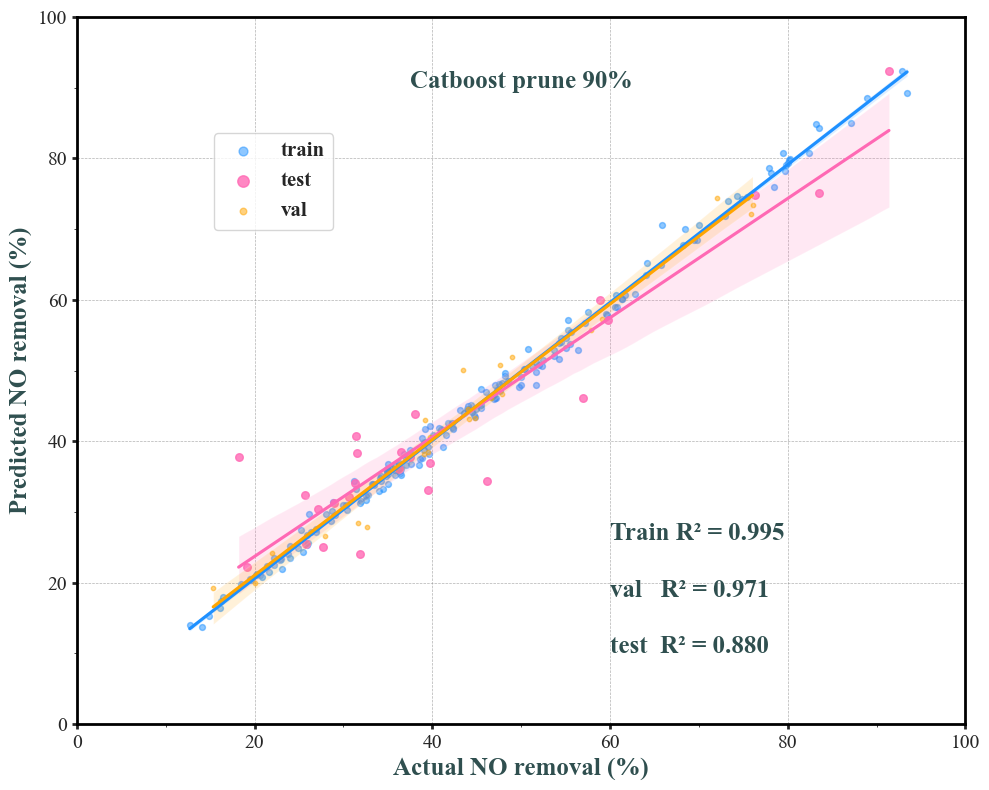

-------------------------------------------------------------------------------
Cat Train 70% mse: 0.00008 | rmse: 0.00891 | mae: 0.00707 | mape: 1.73830 | smape: 1.72872 | r2: 0.99772

Cat val 30% mse: 0.00095 | rmse: 0.03086 | mae: 0.02327 | mape: 5.92487 | smape: 5.92979 | r2: 0.95931

Cat test mse: 0.00346 | rmse: 0.05880 | mae: 0.04288 | mape: 13.86246 | smape: 12.16747 | r2: 0.90465

测试图已保存：scatter_images\Catboost prune 70%.jpg


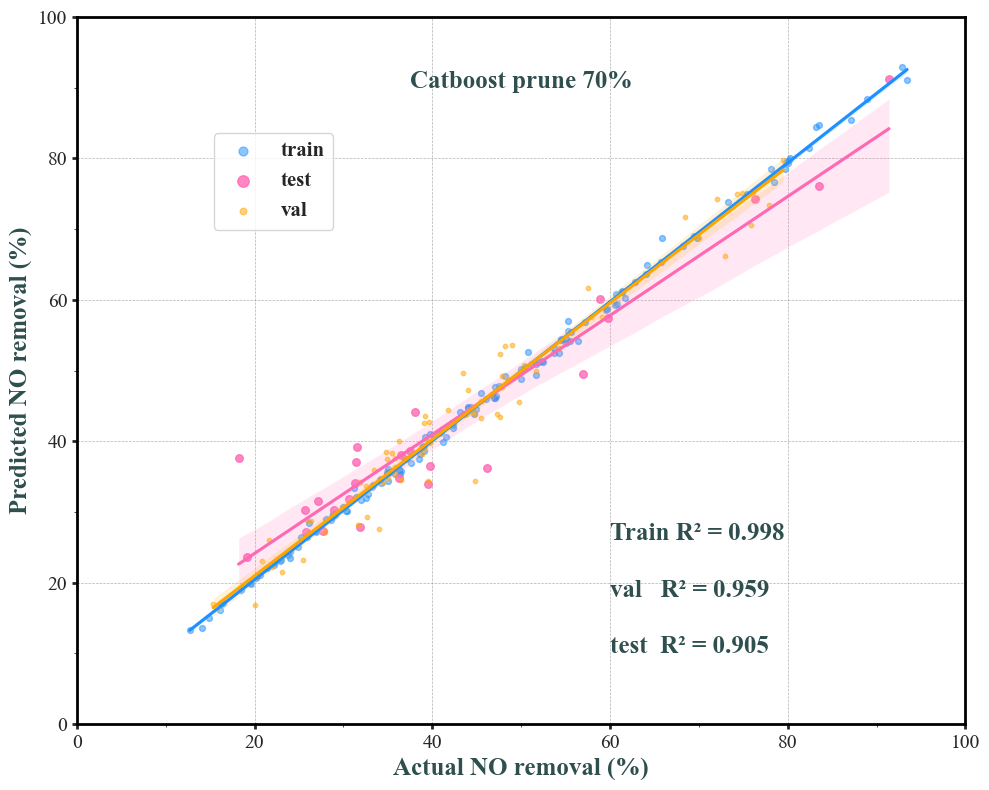

-------------------------------------------------------------------------------
Cat Train 50% mse: 0.00006 | rmse: 0.00769 | mae: 0.00625 | mape: 1.52572 | smape: 1.51696 | r2: 0.99850

Cat val 50% mse: 0.00169 | rmse: 0.04108 | mae: 0.03355 | mape: 8.57495 | smape: 8.33498 | r2: 0.92448

Cat test mse: 0.00419 | rmse: 0.06472 | mae: 0.04886 | mape: 15.39050 | smape: 13.59905 | r2: 0.88450

测试图已保存：scatter_images\Catboost prune 50%.jpg


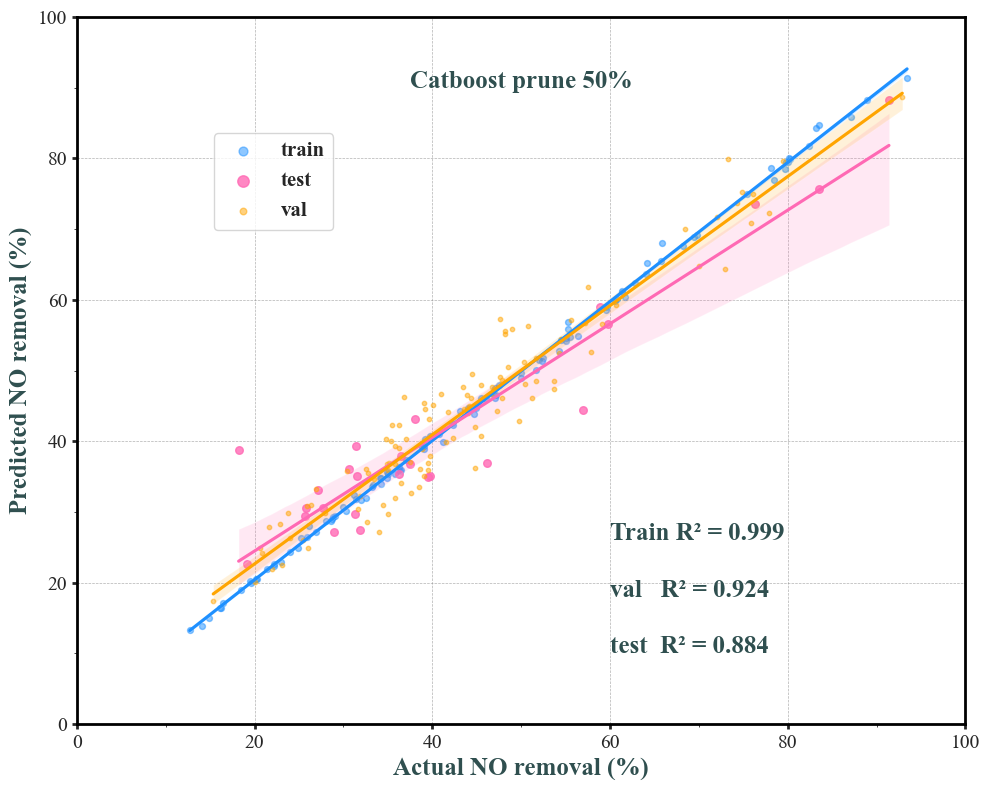

-------------------------------------------------------------------------------
Cat Train 30% mse: 0.00001 | rmse: 0.00248 | mae: 0.00209 | mape: 0.53980 | smape: 0.53847 | r2: 0.99987

Cat val 30% mse: 0.00506 | rmse: 0.07114 | mae: 0.05496 | mape: 14.57337 | smape: 13.50889 | r2: 0.77935

Cat test mse: 0.00647 | rmse: 0.08041 | mae: 0.06206 | mape: 19.63363 | smape: 16.52084 | r2: 0.82171

测试图已保存：scatter_images\Catboost prune 30%.jpg


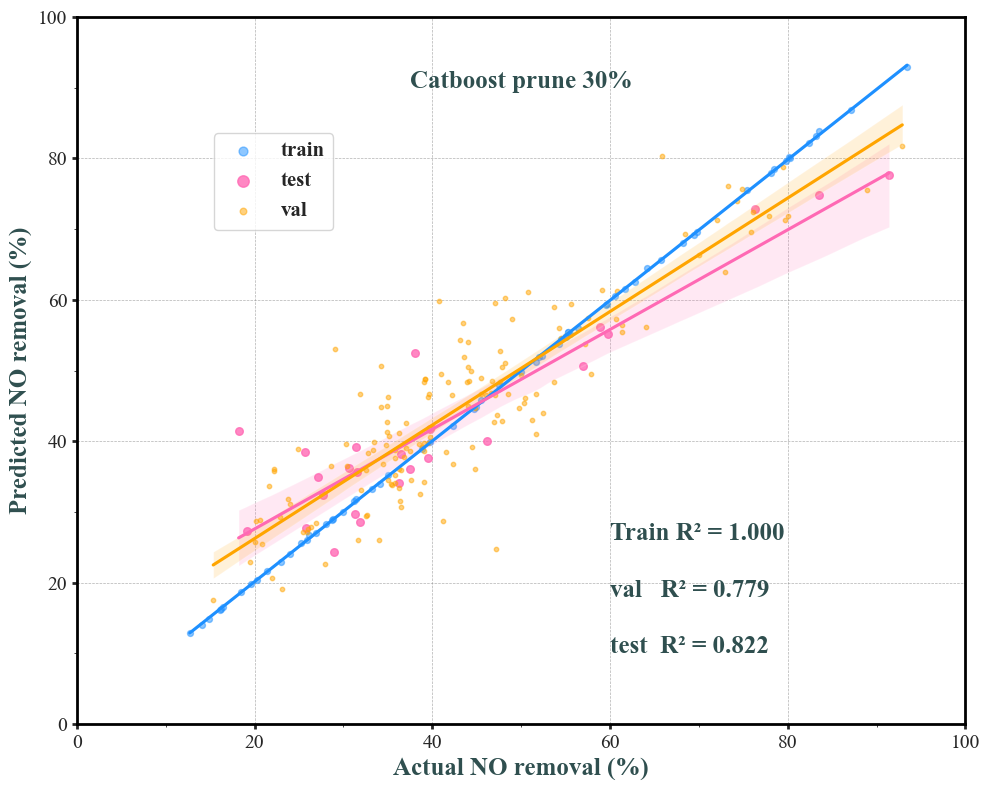

-------------------------------------------------------------------------------


In [45]:
a_count = 0
for i in a_dict.keys():
    df_a = df.loc[remove_a[i]]
    X_train_val = df_a.drop(columns=['NO(%)'])
    y_train_val = df_a['NO(%)']

    df_a_val = df.loc[a_dict[i]]
    X_val = df_a_val.drop(columns=['NO(%)'])
    y_val = df_a_val['NO(%)']

    train_pred, val_pred = process_regressor(model[a],X_train_val,X_val,y_train_val,y_val,cv=False)
    _,test_pred = process_regressor(model[a],X_train_val,X_test,y_train_val,y_test,cv=False)
    if a_count == 0:
        model_performance_metrics('Cat Train 90%', y_train_val, train_pred)
        model_performance_metrics('Cat val 10%', y_val, val_pred)
        model_performance_metrics('Cat val 10%', y_test, test_pred)
        draw_scatter_1(y_train_val, train_pred, y_val,val_pred,y_test, test_pred, "Catboost prune 90%", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

    if a_count == 1:
        model_performance_metrics('Cat Train 70%', y_train_val, train_pred)
        model_performance_metrics('Cat val 30%', y_val, val_pred)
        model_performance_metrics('Cat test', y_test, test_pred)
        draw_scatter_1(y_train_val, train_pred, y_val,val_pred,y_test, test_pred, "Catboost prune 70%", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)
    if a_count == 2:
        model_performance_metrics('Cat Train 50%', y_train_val, train_pred)
        model_performance_metrics('Cat val 50%', y_val, val_pred)
        model_performance_metrics('Cat test', y_test, test_pred)
        draw_scatter_1(y_train_val, train_pred, y_val,val_pred,y_test, test_pred, "Catboost prune 50%", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)
    if a_count == 3:
        model_performance_metrics('Cat Train 30%', y_train_val, train_pred)
        model_performance_metrics('Cat val 30%', y_val, val_pred)
        model_performance_metrics('Cat test', y_test, test_pred)
        draw_scatter_1(y_train_val, train_pred,y_val,val_pred, y_test, test_pred, "Catboost prune 30%", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)
    a_count = a_count+1
    print('-------------------------------------------------------------------------------')


cv train R2: -0.146 (+/- 0.337) 

cv train R2: -0.146 (+/- 0.337) 

XGB Train 90% mse: 0.00059 | rmse: 0.02421 | mae: 0.01889 | mape: 4.85406 | smape: 4.74862 | r2: 0.98216

XGB val 10% mse: 0.00081 | rmse: 0.02848 | mae: 0.02277 | mape: 6.28651 | smape: 6.19229 | r2: 0.96078

XGB val 10% mse: 0.00366 | rmse: 0.06054 | mae: 0.04519 | mape: 13.95614 | smape: 12.63162 | r2: 0.89895

测试图已保存：scatter_images\XGBboost prune 90%.jpg


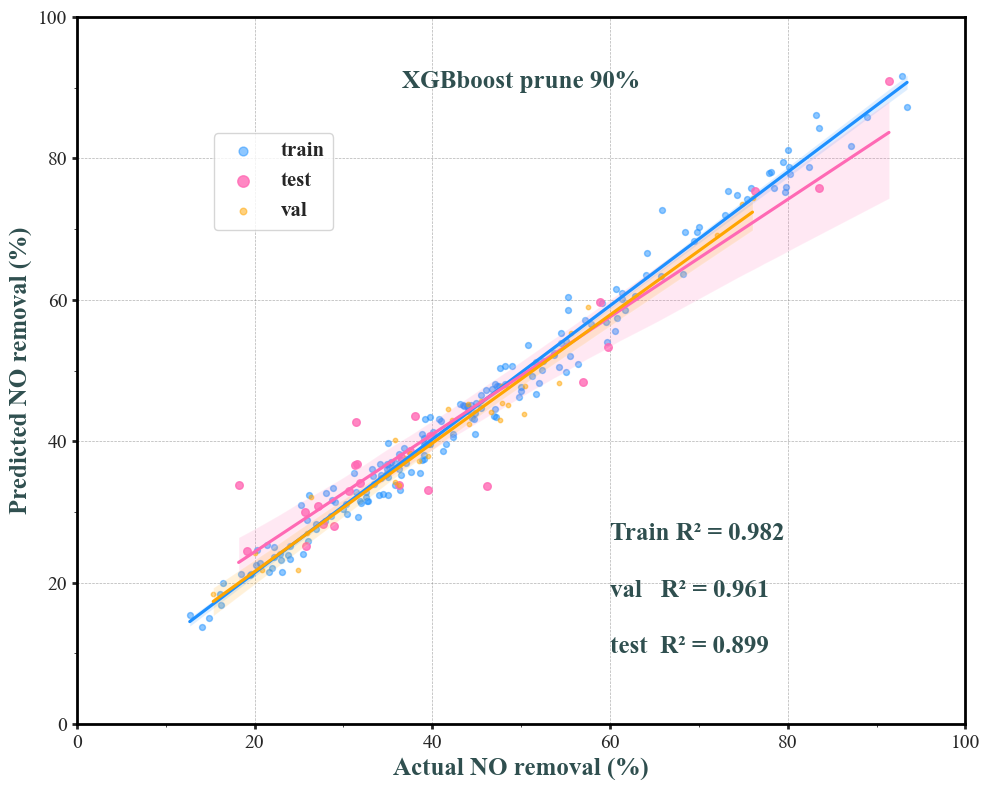

-------------------------------------------------------------------------------
cv train R2: -0.193 (+/- 0.359) 

cv train R2: -0.193 (+/- 0.359) 

XGB Train 70% mse: 0.00051 | rmse: 0.02269 | mae: 0.01779 | mape: 4.60549 | smape: 4.50715 | r2: 0.98545

XGB val 30% mse: 0.00155 | rmse: 0.03935 | mae: 0.03333 | mape: 8.75762 | smape: 8.63407 | r2: 0.92335

XGB test mse: 0.00484 | rmse: 0.06955 | mae: 0.04903 | mape: 14.47416 | smape: 13.06998 | r2: 0.86662

测试图已保存：scatter_images\XGBboost prune 70%.jpg


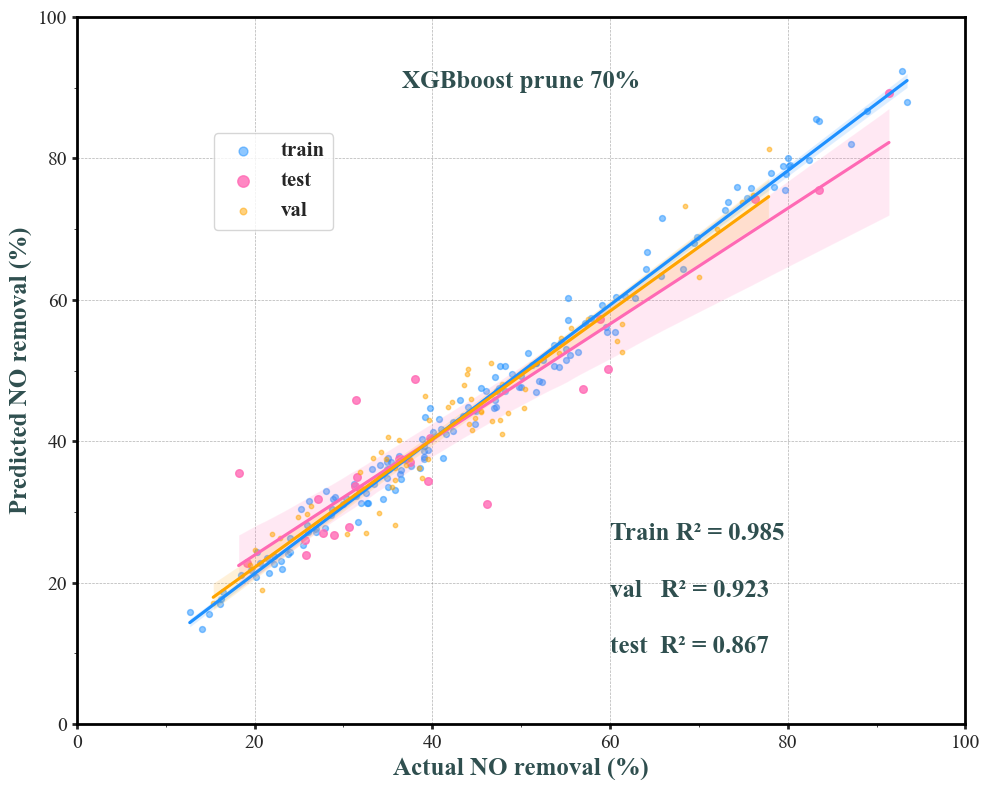

-------------------------------------------------------------------------------
cv train R2: -0.463 (+/- 0.442) 

cv train R2: -0.463 (+/- 0.442) 

XGB Train 50% mse: 0.00034 | rmse: 0.01854 | mae: 0.01468 | mape: 3.77715 | smape: 3.70062 | r2: 0.99071

XGB val 50% mse: 0.00264 | rmse: 0.05140 | mae: 0.03982 | mape: 10.27542 | smape: 10.15900 | r2: 0.89819

XGB test mse: 0.00530 | rmse: 0.07281 | mae: 0.05313 | mape: 16.56561 | smape: 14.37102 | r2: 0.85380

测试图已保存：scatter_images\XGBboost prune 50%.jpg


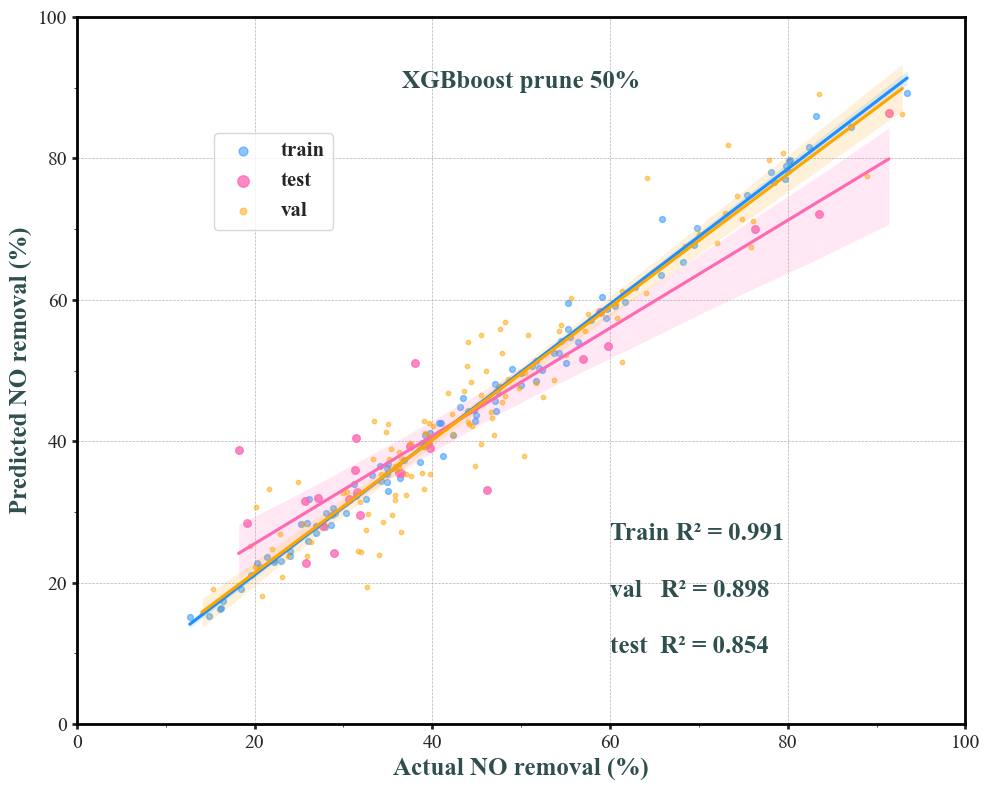

-------------------------------------------------------------------------------
cv train R2: -0.673 (+/- 0.329) 

cv train R2: -0.673 (+/- 0.329) 

XGB Train 30% mse: 0.00016 | rmse: 0.01254 | mae: 0.01019 | mape: 2.77864 | smape: 2.73480 | r2: 0.99675

XGB val 30% mse: 0.00712 | rmse: 0.08435 | mae: 0.06725 | mape: 17.05198 | smape: 15.98816 | r2: 0.70974

XGB test mse: 0.00833 | rmse: 0.09128 | mae: 0.06803 | mape: 19.86534 | smape: 17.84166 | r2: 0.77025

测试图已保存：scatter_images\XGBboost prune 30%.jpg


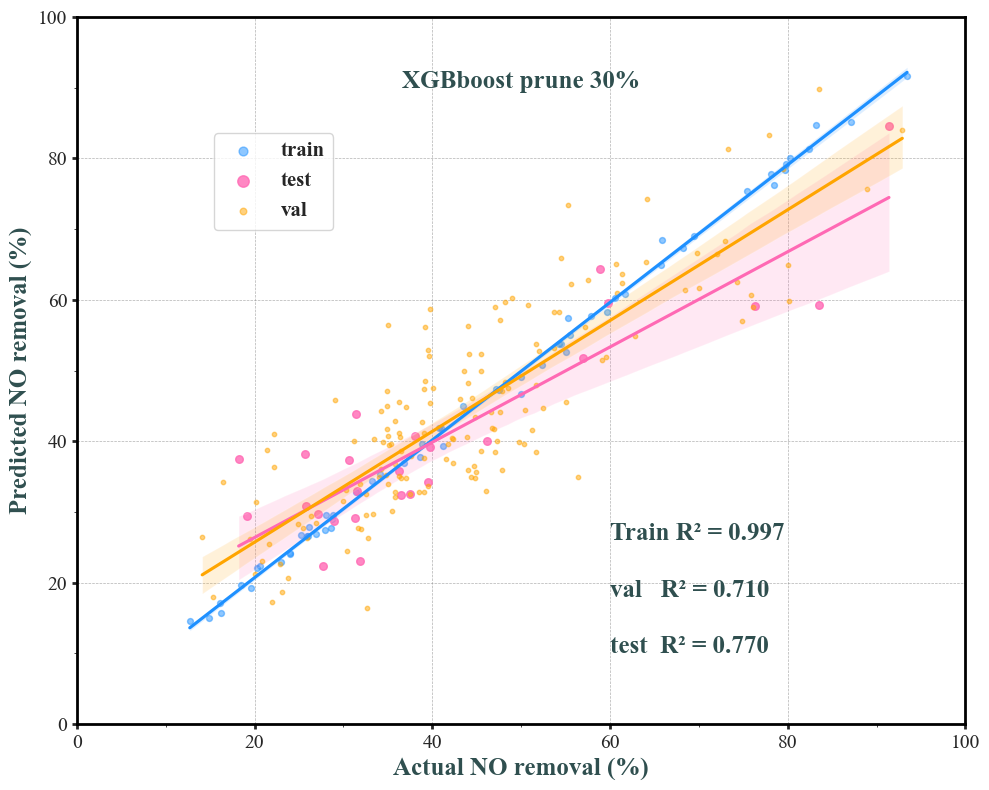

-------------------------------------------------------------------------------


In [46]:
b_count = 0

for i in b_dict.keys():
    df_b = df.loc[remove_b[i]]
    X_train_val = df_b.drop(columns=['NO(%)'])
    y_train_val = df_b['NO(%)']

    df_b_val = df.loc[b_dict[i]]
    X_val = df_b_val.drop(columns=['NO(%)'])
    y_val = df_b_val['NO(%)']
    train_pred, val_pred = process_regressor(model[b],X_train_val,X_val,y_train_val,y_val)
    _,test_pred = process_regressor(model[b],X_train_val,X_test,y_train_val,y_test)
    if b_count == 0:
        model_performance_metrics('XGB Train 90%', y_train_val, train_pred)
        model_performance_metrics('XGB val 10%', y_val, val_pred)
        model_performance_metrics('XGB val 10%', y_test, test_pred)
        draw_scatter_1(y_train_val, train_pred, y_val,val_pred,y_test, test_pred, "XGBboost prune 90%", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

    if b_count == 1:
        model_performance_metrics('XGB Train 70%', y_train_val, train_pred)
        model_performance_metrics('XGB val 30%', y_val, val_pred)
        model_performance_metrics('XGB test', y_test, test_pred)
        draw_scatter_1(y_train_val, train_pred, y_val,val_pred,y_test, test_pred, "XGBboost prune 70%", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)
    if b_count == 2:
        model_performance_metrics('XGB Train 50%', y_train_val, train_pred)
        model_performance_metrics('XGB val 50%', y_val, val_pred)
        model_performance_metrics('XGB test', y_test, test_pred)
        draw_scatter_1(y_train_val, train_pred, y_val,val_pred,y_test, test_pred, "XGBboost prune 50%", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)
    if b_count == 3:
        model_performance_metrics('XGB Train 30%', y_train_val, train_pred)
        model_performance_metrics('XGB val 30%', y_val, val_pred)
        model_performance_metrics('XGB test', y_test, test_pred)
        draw_scatter_1(y_train_val, train_pred,y_val,val_pred, y_test, test_pred, "XGBboost prune 30%", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)
    b_count = b_count+1
    print('-------------------------------------------------------------------------------')


cv train R2: -0.022 (+/- 0.219) 

cv train R2: -0.022 (+/- 0.219) 

GradientBoost Train 90% mse: 0.00001 | rmse: 0.00317 | mae: 0.00254 | mape: 0.64844 | smape: 0.64675 | r2: 0.99969

GradientBoost val 10% mse: 0.00065 | rmse: 0.02548 | mae: 0.01835 | mape: 5.24051 | smape: 5.22241 | r2: 0.97128

GradientBoost val 10% mse: 0.00502 | rmse: 0.07087 | mae: 0.05153 | mape: 16.73883 | smape: 14.61110 | r2: 0.86149

0.8614867273279545
测试图已保存：scatter_images\GradientBoost prune 90%.jpg


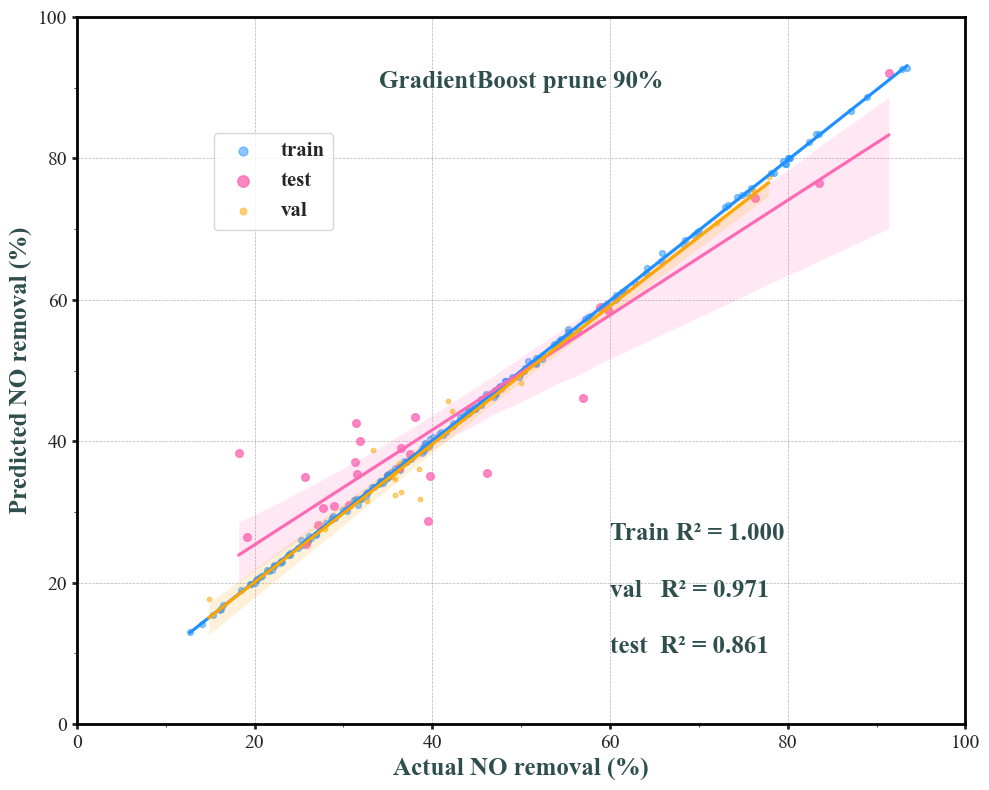

-------------------------------------------------------------------------------
cv train R2: 0.009 (+/- 0.226) 

cv train R2: 0.009 (+/- 0.226) 

GradientBoost Train 70% mse: 0.00001 | rmse: 0.00331 | mae: 0.00275 | mape: 0.70646 | smape: 0.70440 | r2: 0.99968

GradientBoost val 30% mse: 0.00170 | rmse: 0.04118 | mae: 0.03227 | mape: 8.54976 | smape: 8.37605 | r2: 0.92516

GradientBoost test mse: 0.00465 | rmse: 0.06819 | mae: 0.05461 | mape: 17.10435 | smape: 15.35287 | r2: 0.87179

测试图已保存：scatter_images\GradientBoost prune 70%.jpg


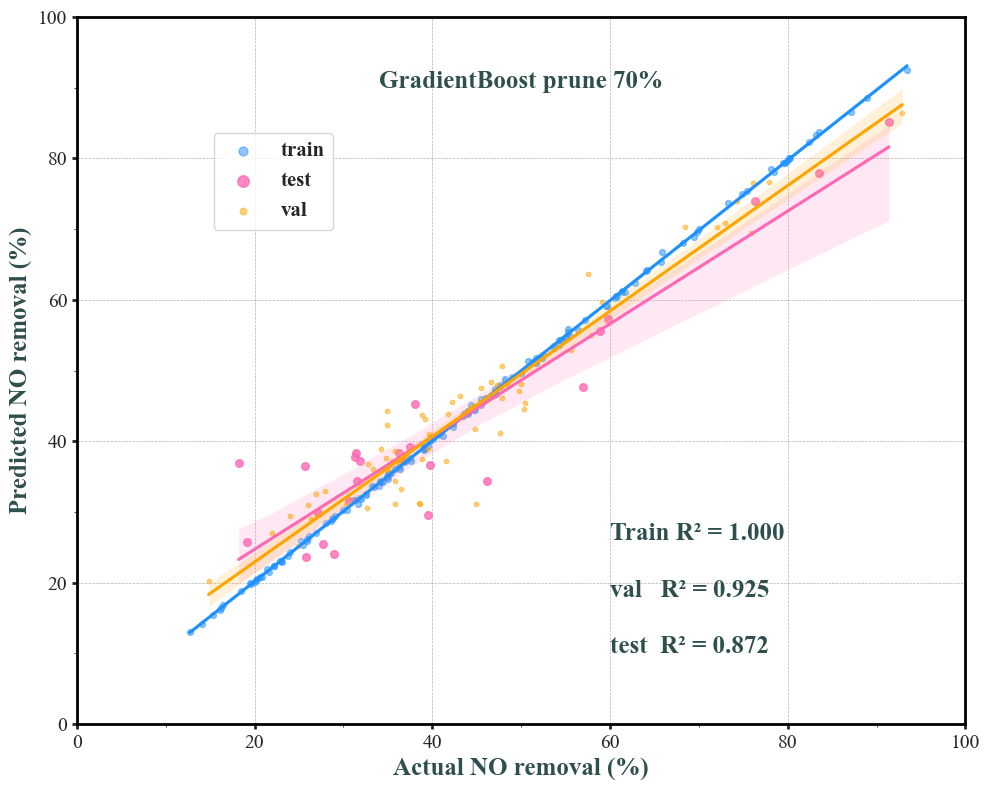

-------------------------------------------------------------------------------
cv train R2: -0.167 (+/- 0.370) 

cv train R2: -0.167 (+/- 0.370) 

GradientBoost Train 50% mse: 0.00001 | rmse: 0.00293 | mae: 0.00250 | mape: 0.64698 | smape: 0.64515 | r2: 0.99979

GradientBoost val 50% mse: 0.00392 | rmse: 0.06258 | mae: 0.05282 | mape: 13.98082 | smape: 13.26090 | r2: 0.81724

GradientBoost test mse: 0.00720 | rmse: 0.08486 | mae: 0.06169 | mape: 19.23480 | smape: 16.47393 | r2: 0.80143

测试图已保存：scatter_images\GradientBoost prune 50%.jpg


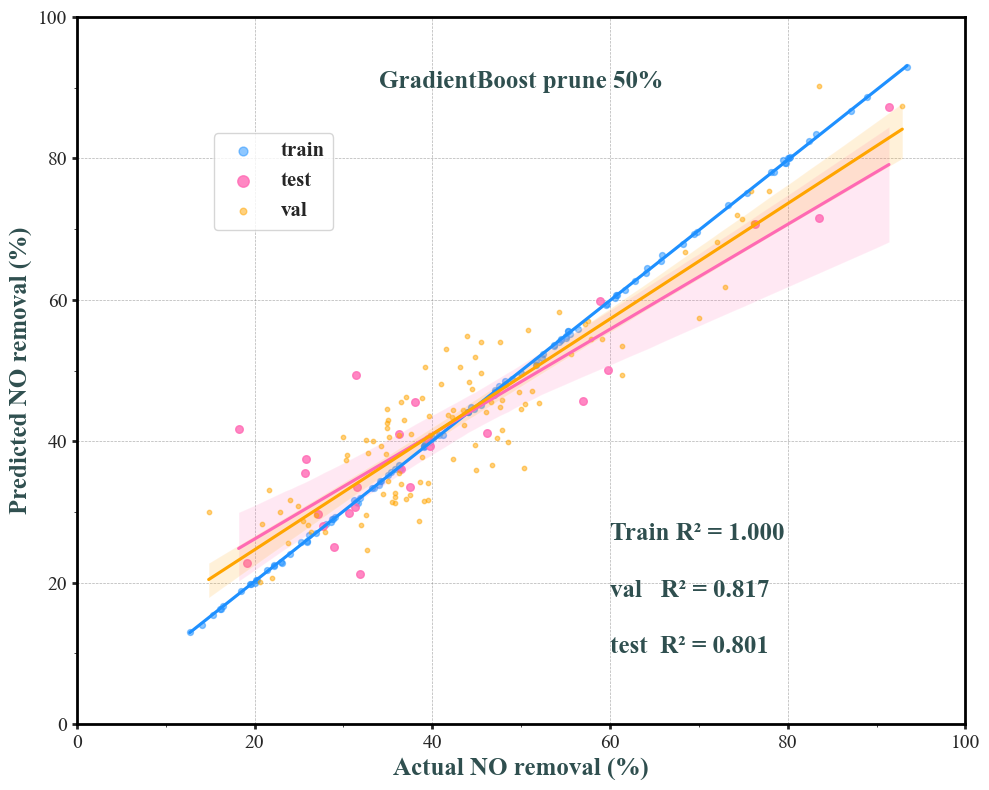

-------------------------------------------------------------------------------
cv train R2: -0.367 (+/- 0.278) 

cv train R2: -0.367 (+/- 0.278) 

GradientBoost Train 30% mse: 0.00001 | rmse: 0.00243 | mae: 0.00201 | mape: 0.53062 | smape: 0.52926 | r2: 0.99989

GradientBoost val 30% mse: 0.00858 | rmse: 0.09262 | mae: 0.07533 | mape: 18.27555 | smape: 17.47050 | r2: 0.61721

GradientBoost test mse: 0.00813 | rmse: 0.09014 | mae: 0.06319 | mape: 20.00963 | smape: 16.52663 | r2: 0.77593

测试图已保存：scatter_images\GradientBoost prune 30%.jpg


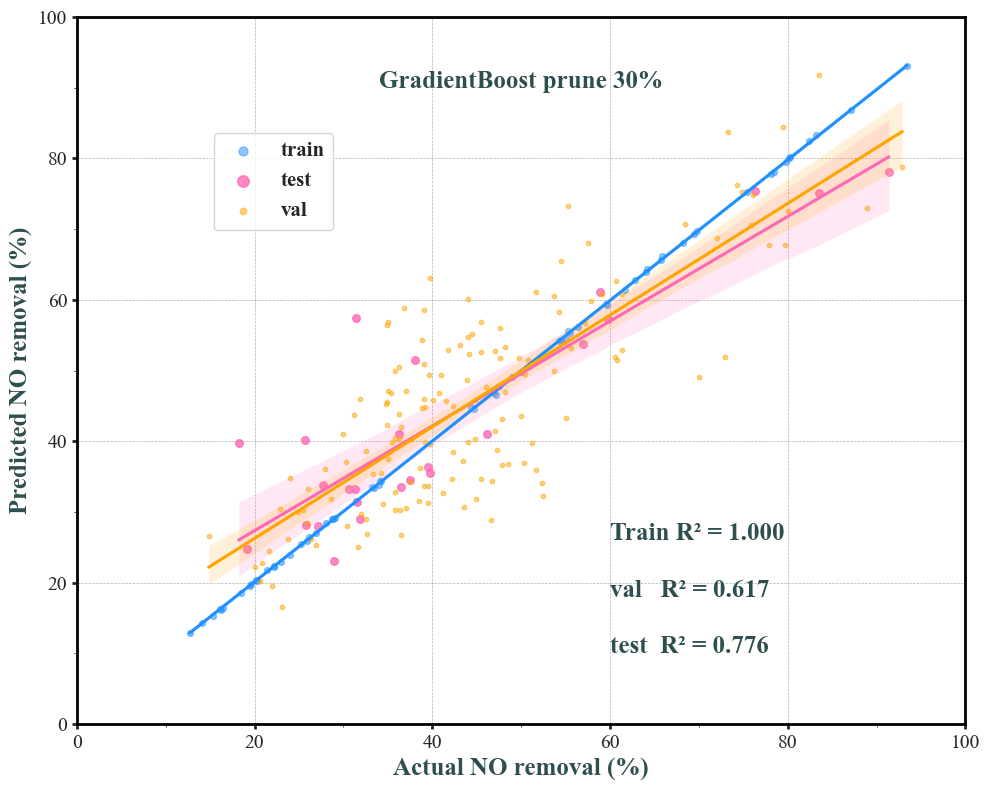

-------------------------------------------------------------------------------


In [47]:
c_count = 0
from sklearn import metrics
for i in c_dict.keys():

    df_c = df.loc[remove_c[i]]
    X_train_val = df_c.drop(columns=['NO(%)'])
    y_train_val = df_c['NO(%)']

    df_c_val = df.loc[c_dict[i]]
    X_val = df_c_val.drop(columns=['NO(%)'])
    y_val = df_c_val['NO(%)']

    train_pred, val_pred = process_regressor(model[c],X_train_val,X_val,y_train_val,y_val,cv=True)
    _,test_pred = process_regressor(model[c],X_train_val,X_test,y_train_val,y_test,cv=True)
    if c_count == 0:
        model_performance_metrics('GradientBoost Train 90%', y_train_val, train_pred)
        model_performance_metrics('GradientBoost val 10%', y_val, val_pred)
        model_performance_metrics('GradientBoost val 10%', y_test, test_pred)
        print(metrics.r2_score(y_test, test_pred))
        draw_scatter_1(y_train_val, train_pred, y_val,val_pred,y_test, test_pred, "GradientBoost prune 90%", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

    if c_count == 1:
        model_performance_metrics('GradientBoost Train 70%', y_train_val, train_pred)
        model_performance_metrics('GradientBoost val 30%', y_val, val_pred)
        model_performance_metrics('GradientBoost test', y_test, test_pred)
        draw_scatter_1(y_train_val, train_pred, y_val,val_pred,y_test, test_pred, "GradientBoost prune 70%", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)
    if c_count == 2:
        model_performance_metrics('GradientBoost Train 50%', y_train_val, train_pred)
        model_performance_metrics('GradientBoost val 50%', y_val, val_pred)
        model_performance_metrics('GradientBoost test', y_test, test_pred)
        draw_scatter_1(y_train_val, train_pred, y_val,val_pred,y_test, test_pred, "GradientBoost prune 50%", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)
    if c_count == 3:
        model_performance_metrics('GradientBoost Train 30%', y_train_val, train_pred)
        model_performance_metrics('GradientBoost val 30%', y_val, val_pred)
        model_performance_metrics('GradientBoost test', y_test, test_pred)
        draw_scatter_1(y_train_val, train_pred,y_val,val_pred, y_test, test_pred, "GradientBoost prune 30%", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)
    c_count = c_count+1
    print('-------------------------------------------------------------------------------')


In [40]:
full = {}
full['id'] = df.index.tolist()

In [41]:
a_count = []
for i in range(0,80):
    aaaaaaa = {}
    aaaaaaa['id']= list(set(full['id']) - set(remove_a[i]))
    df_a = df.loc[remove_a[i]]
    X_train_val = df_a.drop(columns=['NO(%)'])
    y_train_val = df_a['NO(%)']

    df_a_val = df.loc[aaaaaaa['id']]
    X_val = df_a_val.drop(columns=['NO(%)'])
    y_val = df_a_val['NO(%)']
    train_pred, val_pred = process_regressor(model[a],X_train_val,X_val,y_train_val,y_val,cv=False)
    model_performance_metrics('Cat Train 90%', y_train_val, train_pred)
    abc = model_performance_metrics('Cat val 10%', y_val, val_pred)
    print('______-----------------------------------------')
    a_count.append(abc)

a_count = pd.DataFrame(a_count, columns=['ID'])
df_111 = a_count.sort_values(by = 'ID')
print(df_111)

Cat Train 90% mse: 0.00019 | rmse: 0.01369 | mae: 0.01031 | mape: 2.60356 | smape: 2.57617 | r2: 0.99397

Cat val 10% mse: 0.00354 | rmse: 0.05952 | mae: 0.04616 | mape: 14.54131 | smape: 13.16598 | r2: 0.90230

______-----------------------------------------
Cat Train 90% mse: 0.00019 | rmse: 0.01366 | mae: 0.01041 | mape: 2.59623 | smape: 2.56898 | r2: 0.99396

Cat val 10% mse: 0.00327 | rmse: 0.05722 | mae: 0.04230 | mape: 13.09473 | smape: 11.74246 | r2: 0.91176

______-----------------------------------------
Cat Train 90% mse: 0.00017 | rmse: 0.01310 | mae: 0.01008 | mape: 2.54662 | smape: 2.52126 | r2: 0.99454

Cat val 10% mse: 0.00288 | rmse: 0.05369 | mae: 0.03804 | mape: 11.77311 | smape: 10.49798 | r2: 0.91201

______-----------------------------------------
Cat Train 90% mse: 0.00017 | rmse: 0.01302 | mae: 0.01016 | mape: 2.54587 | smape: 2.52093 | r2: 0.99454

Cat val 10% mse: 0.00282 | rmse: 0.05313 | mae: 0.03818 | mape: 11.88312 | smape: 10.69443 | r2: 0.91848

______--

KeyboardInterrupt: 

In [ ]:
aaaaaaa = {}
aaaaaaa['id']= list(set(full['id']) - set(remove_a[20]))

In [ ]:
aaaaaaa = {}
aaaaaaa['id']= list(set(full['id']) - set(remove_a[22]))
df_a = df.loc[remove_a[22]]
df_a_val = df.loc[aaaaaaa['id']]

df_a.to_csv('prune_train.csv', index=False)
df_a_val.to_csv('prune_test.csv', index=False)

In [ ]:
a_count = []
for i in range(0,80):
    aaaaaaa = {}
    aaaaaaa['id']= list(set(full['id']) - set(remove_b[i]))
    df_a = df.loc[remove_b[i]]
    X_train_val = df_a.drop(columns=['NO(%)'])
    y_train_val = df_a['NO(%)']

    df_a_val = df.loc[aaaaaaa['id']]
    X_val = df_a_val.drop(columns=['NO(%)'])
    y_val = df_a_val['NO(%)']
    train_pred, val_pred = process_regressor(model[b],X_train_val,X_val,y_train_val,y_val,cv=False)
    model_performance_metrics('Cat Train 90%', y_train_val, train_pred)
    abc = model_performance_metrics('Cat val 10%', y_val, val_pred)
    print('______-----------------------------------------')
    a_count.append(abc)

a_count = pd.DataFrame(a_count, columns=['ID'])
df_111 = a_count.sort_values(by = 'ID')
print(df_111)

In [ ]:
a_count = []
for i in range(0,80):
    aaaaaaa = {}
    aaaaaaa['id']= list(set(full['id']) - set(remove_c[i]))
    df_a = df.loc[remove_c[i]]
    X_train_val = df_a.drop(columns=['NO(%)'])
    y_train_val = df_a['NO(%)']

    df_a_val = df.loc[aaaaaaa['id']]
    X_val = df_a_val.drop(columns=['NO(%)'])
    y_val = df_a_val['NO(%)']
    train_pred, val_pred = process_regressor(model[c],X_train_val,X_val,y_train_val,y_val,cv=False)
    model_performance_metrics('Cat Train 90%', y_train_val, train_pred)
    abc = model_performance_metrics('Cat val 10%', y_val, val_pred)
    print('______-----------------------------------------')
    a_count.append(abc)

a_count = pd.DataFrame(a_count, columns=['ID'])
df_111 = a_count.sort_values(by = 'ID')
print(df_111)

In [ ]:
X_train_val

In [ ]:
import pandas as pd
a_list = []
b_list = []
c_list = []
for i in range(0,80):
    a_list.append(len(remove_a[i]))
    b_list.append(len(remove_b[i]))
    c_list.append(len(remove_c[i]))
df_a = pd.DataFrame(a_list)
df_b = pd.DataFrame(b_list)
df_c = pd.DataFrame(c_list)

In [ ]:
test_scores_c = pd.DataFrame(test_scores_c)
val_scores_c = pd.DataFrame(val_scores_c)
test_fit_c = pd.DataFrame(test_fit_c)

test_scores_a = pd.DataFrame(test_scores_a)
val_scores_a = pd.DataFrame(val_scores_a)
test_fit= pd.DataFrame(test_fit_a)

test_scores_b = pd.DataFrame(test_scores_b)
val_scores_b = pd.DataFrame(val_scores_b)
test_fit_b = pd.DataFrame(test_fit_b)


In [ ]:

test_scores_a.to_csv('test_scores_a.csv')
val_scores_a.to_csv('val_scores_a.csv')
df_c.to_csv('df_c.csv')
df_a.to_csv('df_a.csv')
df_b.to_csv('df_b.csv')
test_scores_b.to_csv('test_scores_b.csv')
val_scores_b.to_csv('val_scores_b.csv')
test_fit_b.to_csv('test_fit_b.csv')
test_scores_c.to_csv('test_scores_c.csv')
val_scores_c.to_csv('val_scores_c.csv')
test_fit_c.to_csv('test_fit_c.csv')
test_fit.to_csv('test_fit.csv')

In [ ]:
df,X,y,X_train_val,X_test,y_train_val,y_test = get_data(target = target,random_state=random_state, test_size=test_size,standardized=False)

In [ ]:

df.loc[remove_a[20]].to_csv('70%.csv')
df.loc[a].to_csv('100%.csv')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
def draw_violin_1(data, config, which,model = '',bw_method='scott',count = '100%', save=False):

    # 初始化设置
    plt.rcParams['font.family'] = 'Times New Roman'
    cfg = config[which]
    bw_method = cfg.get('bw_method', bw_method)

    # 数据预处理
    data = data[which].values.ravel()
    scale_data = data * cfg['scale']

    # 自动计算区间范围

    min_val, max_val = scale_data.min(), scale_data.max()
    step = cfg['step'] * cfg['scale']

    scale_begin = max(0, int(min_val - step)) if cfg['begin'] < 0 else cfg['begin']
    scale_end = int(max_val + step + 1) if cfg['end'] < 0 else cfg['end']

    bins = range(scale_begin, scale_end, int(step))
    segments = pd.cut(scale_data, bins)

    mid_mapping = {
        interval: interval.mid / cfg['scale']
        for interval in segments.categories
    }

    # 将数据进行进一步集中计数
    mid_points = segments.rename_categories(mid_mapping).astype(float)

    # 绘图核心
    plt.figure(figsize=cfg.get('figsize', (8, 6)))

    # 使用上下文管理器优化绘图参数
    with sns.axes_style("whitegrid"):
        ax = sns.violinplot(
            x=mid_points,
            inner='box',
            bw_method=bw_method,
            color=cfg['color'],
            linewidth=cfg.get('linewidth', 1),
            saturation=cfg.get('saturation', 0.75),
            alpha = cfg.get('alpha',0.7)
        )

    # 添加文本注释cfg['text_x'],cfg['text_y']设定第三个参数出现位置，分别位于x，y处
    plt.text(x = cfg['text_x'],y =cfg['text_y'],s = model +' '+count+' '+ cfg['text'] ,family='Times New Roman', weight='bold',
             size=(cfg['xtick_size']),
             horizontalalignment='center',
             transform=plt.gcf().transFigure,
             verticalalignment='top',)
    # 设置x轴刻度
    plt.xticks(fontproperties='Times New Roman', size=cfg['xtick_size'], weight='bold')

    # 隐藏y轴刻度和标签
    plt.yticks(fontproperties='Times New Roman', size=20, weight='bold')
    '''
    plt.ylabel(
        "Amplitude (m)",  # 标签文本
        fontsize=12,  # 字体大小
        color='blue',  # 字体颜色
        fontweight='bold',  # 字体粗细 ('normal', 'bold', 'heavy')
        fontfamily='Times New Roman',  # 字体类型
        rotation=90,  # 旋转角度（0~360 或 'vertical'/'horizontal'）
        labelpad=30  # 标签与轴的距离（像素）
    )
    '''
    # 设置刻度样式
    plt.tick_params(direction="in", width=2)

    # 设置y轴范围
    plt.ylim(cfg['ylim_left'], cfg['ylim_right'])

    # 获取坐标轴对象ax
    ax = plt.gca()

    #设置x轴名称标签
    ax.set_xlabel(
    cfg['xlabel'],
    fontproperties='Times New Roman',  # 字体
    size=20,                           # 字体大小
    weight='bold',                     # 字体加粗
    labelpad=2                        # 标题与 x 轴的距离
                )
    #设置x轴刻度标签
    ax.set_xticklabels(
    ax.get_xticklabels(),
    fontproperties='Times New Roman',  # 字体
    size=20,                           # 字体大小
    weight='bold',                     # 字体加粗
    rotation=0,                       # 旋转角度
    ha='right',                        # 水平对齐方式
    va='top',                          # 垂直对齐方式
    )
    ax.xaxis.set_tick_params(pad=15)   # 标签与 x 轴的距离
    #设置y轴刻度标签
    ax.set_yticks([cfg['ylim_left'],cfg['ylim_left']/2,0,cfg['ylim_right']/2,cfg['ylim_right']])  # 主刻度位置
    ax.set_yticklabels([cfg['ylim_left'],cfg['ylim_left']/2,0,cfg['ylim_right']/2,cfg['ylim_right']])  # 主刻度标签
    # 设置坐标轴边框宽度
    for spine in ax.spines.values():
        spine.set_linewidth(cfg['bound_width'])
        spine.set_color('black')
    #设置图内网格
    plt.grid(True,
             axis='both',
             linestyle='--',
             linewidth=0.5,
             color='gray',
             alpha=0.6)
    # 调整图形布局
    plt.subplots_adjust(top=0.9, bottom=0.1, left=0.1, right=0.9)

    # 保存图像

    if save:
        output_dir = 'violin_images'
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
        output_path = os.path.join(output_dir, f'{cfg['image_name']+ model + count}.jpg')
        plt.savefig(output_path, format="jpg", dpi=600,
                    bbox_inches="tight",
                    pil_kwargs={'quality': 95})
        print(f"小提琴图已保存：{output_path}")
    # 显示图形
    plt.show()

violin_config_100 = {
    'NO(%)': {
        'begin': -1,
        'end': -1,
        'step': 25,
        'scale': 1,
        'text': 'NO removal (%)',
        'text_size': 28,
        'text_x': 0.5,
        'text_y': 0.85,
        'bound_width': 2,
        'color': '#FFBFC5',
        'ylim_left': -0.7,
        'ylim_right': 0.7,
        'xtick_size': 20,
        'xlabel':'NO removal (%)',
        'bw' : 0.1,
        'image_name': '100_NOx',
        'saturation': 0.75,
        'alpha': 0.7,
        'line_width' : 1},
    'BET(m2/g)': {
        'begin': -1,
        'end': -1,
        'step': 20,
        'scale': 1,
        'text': 'BET (m²/g)',
        'text_size': 28,
        'text_x': 0.5,
        'text_y': 0.85,
        'bound_width': 2,
        'color': '#98FF98',
        'ylim_left': -0.7,
        'ylim_right': 0.7,
        'xtick_size': 20,
        'xlabel':'BET (m²/g)',
        'image_name': '100BET',
        'bw_method' : 0.1,
        'saturation': 0.75,
        'alpha': 0.7,
        'line_width' : 1},
    'Eg(eV)': {
            'begin': -1,
            'end': -1,
            'step': 0.2,
            'scale': 5,
            'text': 'Band gap (eV)',
            'text_size': 28,
            'text_x': 0.5,
            'text_y': 0.85,
            'bound_width': 2,
            'color': '#87CEEB',
            'ylim_left': -0.7,
            'ylim_right': 0.7,
            'xtick_size': 20,
            'xlabel':'Band gap (eV)',
            'image_name': '100_Eg',
            'bw_method': 0.2,
            'saturation': 0.75,
            'alpha': 0.7,
            'line_width' : 1},
    'NO2(%)': {
            'begin': -1,
            'end': -1,
            'step': 15,
            'scale': 1,
            'text': 'NO₂ generation (%)',
            'text_size': 28,
            'text_x': 0.5,
            'text_y': 0.85,
            'bound_width': 2,
            'color': '#FFFDD0',
            'ylim_left': -0.7,
            'ylim_right': 0.7,
            'xtick_size': 20,
            'xlabel':'NO₂ generation (%)',
            'image_name': '100_NO2',
            'bw_method': 0.2,
            'saturation': 0.75,
            'alpha': 0.5,
            'line_width' : 1},
    'Time(h)': {
            'begin': -1,
            'end': -1,
            'step': 1.5,
            'scale': 20,
            'text': 'Calcination time (h)',
            'text_size': 28,
            'text_x': 0.5,
            'text_y': 0.85,
            'bound_width': 2,
            'color': '#E6E6FA',
            'ylim_left': -0.7,
            'ylim_right': 0.7,
            'xtick_size': 20,
            'xlabel':'Calcination time (h)',
            'image_name': '100_CT',
            'bw_method': 0.2,
            'saturation': 0.75,
            'alpha': 0.7,
            'line_width' : 1},
    'Heat(℃)': {
            'begin': -1,
            'end': -1,
            'step': 50,
            'scale': 1,
            'text': 'Temperature (℃)',
            'text_size': 28,
            'text_x': 0.5,
            'text_y': 0.85,
            'bound_width': 2,
            'color': '#FF7F50',
            'ylim_left': -0.7,
            'ylim_right': 0.7,
            'xtick_size': 20,
            'xlabel':'Temperature (℃)',
            'image_name': '100_T',
            'bw_method': 0.2,
            'saturation': 0.75,
            'alpha': 0.7,
            'line_width' : 1},
    'PM(g)': {
            'begin': -1,
            'end': -1,
            'step': 7.5,
            'scale': 1,
            'text': 'Precursor masses (g)',
            'text_size': 28,
            'text_x': 0.5,
            'text_y': 0.85,
            'bound_width': 2,
            'color': '#000080',
            'ylim_left': -0.7,
            'ylim_right': 0.7,
            'xtick_size': 20,
            'xlabel':'Precursor masses (g)',
            'image_name': '100_PM(g)',
            'bw_method': 0.2,
            'saturation': 0.75,
            'alpha': 0.7,
            'line_width' : 1},
    'NO(ppm)': {
            'begin': -1,
            'end': -1,
            'step': 20,
            'scale': 1,
            'text': 'NO (ppm)',
            'text_size': 28,
            'text_x': 0.5,
            'text_y': 0.85,
            'bound_width': 2,
            'color': '#8B0000',
            'ylim_left': -0.7,
            'ylim_right': 0.7,
            'xtick_size': 20,
            'xlabel':'NO(ppm)',
            'image_name': '100_NO (ppm)',
            'bw_method': 0.4,
            'saturation': 0.75,
            'alpha': 0.7,
            'line_width' : 1},
    'HR(℃/min)': {
            'begin': -1,
            'end': -1,
            'step': 15,
            'scale': 1,
            'text': 'Heating rate (℃/min)',
            'text_size': 28,
            'text_x': 0.5,
            'text_y': 0.85,
            'bound_width': 2,
            'color': '#006400',
            'ylim_left': -0.7,
            'ylim_right': 0.7,
            'xtick_size': 20,
            'xlabel':'Heating rate (℃/min)',
            'image_name': '100_HR',
            'bw_method': 0.2,
            'saturation': 0.75,
            'alpha': 0.7,
            'line_width' : 1},
    'ratio(%)': {
            'begin': -1,
            'end': -1,
            'step': 200,
            'scale': 1,
            'text': 'ratio (wt%)',
            'text_size': 40,
            'text_x': 0.5,
            'text_y': 0.85,
            'bound_width': 2,
            'color': '#4B0082',
            'ylim_left': -0.7,
            'ylim_right': 0.7,
            'xtick_size': 20,
            'xlabel':'Ratio (wt%)',
            'image_name': '100_ratio (wt%)',
            'bw_method': 0.3,
            'saturation': 0.75,
            'alpha': 0.7,
            'line_width' : 1},
    'load(g)': {
            'begin': -1,
            'end': -1,
            'step': 0.1,
            'scale': 100,
            'text': '"Load of catalyst (g)"',
            'text_size': 28,
            'text_x': 0.5,
            'text_y': 0.85,
            'bound_width': 2,
            'color': '#B8860B',
            'ylim_left': -0.7,
            'ylim_right': 0.7,
            'xtick_size': 20,
            'xlabel':'Load of catalyst (g)',
            'image_name': '100_Load',
            'bw_method': 0.2,
            'saturation': 0.75,
            'alpha': 0.7,
            'line_width' : 1},
    'Intensity(W)': {
            'begin': -1,
            'end': -1,
            'step': 100,
            'scale': 1,
            'text': 'Light intensity (W)',
            'text_size': 28,
            'text_x': 0.5,
            'text_y': 0.85,
            'bound_width': 2,
            'color': '#0ABAB5',
            'ylim_left': -0.7,
            'ylim_right': 0.7,
            'xtick_size': 20,
            'xlabel':'Light Intensity (W)',
            'image_name': '100_Intensity',
            'bw_method': 0.2,
            'saturation': 0.75,
            'alpha': 0.7,
            'line_width' : 1},
    'rate(mL/min)': {
            'begin': -1,
            'end': -1,
            'step': 1000,
            'scale': 10,
            'text': 'Flow rate (L/min)',
            'text_size': 28,
            'text_x': 0.5,
            'text_y': 0.85,
            'bound_width': 2,
            'color': '#F3CFC6',
            'ylim_left': -0.7,
            'ylim_right': 0.7,
            'xtick_size': 20,
            'xlabel':'Flow rate (L/min)',
            'image_name': '100_flow_rate',
            'bw_method': 0.3,
            'saturation': 0.75,
            'alpha': 0.7,
            'line_width' : 1},
    'area(cm2)': {
            'begin': -1,
            'end': -1,
            'step': 50,
            'scale': 1,
            'text': 'area (cm²)',
            'text_size': 28,
            'text_x': 0.5,
            'text_y': 0.85,
            'bound_width': 2,
            'color': '#8AA39B',
            'ylim_left': -0.7,
            'ylim_right': 0.7,
            'xtick_size': 20,
            'xlabel':'area (cm²)',
            'image_name': '100_area(cm2)',
            'bw_method': 0.2,
            'saturation': 0.75,
            'alpha': 0.7,
            'line_width' : 1},
}